# Wind Turbine Structural Damage Detection: Signal Processing & ML Training Pipeline

**Author:** Alexey David Velásquez Betancurt · EIA University, Medellín, Colombia

End-to-end pipeline that turns raw tower-mounted accelerometer recordings from a 14 m
prototype wind turbine into trained machine-learning classifiers that (1) detect
structural damage and (2) locate it along the mast. Damage was physically induced by
manipulating the tension of the guy wires that stiffen the tower, and 6,000+ vibration
records were collected over a 1.5-year experimental campaign.

> **Note on data availability.** The accelerometry dataset belongs to a research project
> at EIA University and is not publicly available. All cell outputs (metrics, tables and
> figures) are preserved from the original training runs so the full pipeline can be
> reviewed without re-executing it.
>
> **Glossary for labels that appear in outputs and figures**: the acquisition system
> was configured in Spanish: *Este/Norte* = East/North sensor axis; *Categoría_Binaria*
> = binary target (healthy/damaged); *Categoría_Multiclase* = damage-location target
> (healthy, top, bottom, top-bottom); *TodoApretado / TodoDesapretado* = all guy wires
> tightened / loosened; *C1-C8* = individual guy-wire damage scenarios.


# 1. Introduction

This notebook is the machine-learning baseline of the thesis methodology. It covers the
complete path from raw acceleration signals to deployable classifiers:

1. **Signal preprocessing**: detrending, Hann smoothing, Butterworth band-pass
   filtering and resampling of raw accelerometer records.
2. **Modal feature extraction**: Frequency Domain Decomposition (FDD): cross spectral
   density matrices between sensor pairs, singular value decomposition, and peak picking
   of the five dominant natural frequencies per axis (10 features per record).
3. **Data preparation**: class balancing, IQR-based outlier treatment and dataset
   assembly for two supervised tasks.
4. **Model training**: five algorithm families (SVM, KNN, Random Forest, Gradient
   Boosting, LightGBM) trained and tuned with stratified 10-fold cross-validation for
   **damage detection** (binary) and **damage localization** (multiclass), then compared
   on a held-out test set.

# 2. Libraries

In [1]:
# General utilities
import glob
import os
import math

# Data analysis
import numpy as np
import pandas as pd
import seaborn as sns
from nptdms import TdmsFile

# Signal filtering and processing
from matplotlib import pyplot as plt
import matplotlib as mpl
from scipy.linalg import svd
from scipy.signal import detrend, resample, butter, lfilter, argrelextrema, csd

# Machine learning
import shap
from pycaret.classification import *

# Model persistence
from pathlib import Path

# Thesis formatting convention for every figure
mpl.rcParams['font.family'] = 'Times New Roman'

# 3. Dataset Definition & Processing Configuration

## 3.1 Campaign labels and I/O paths

Each acquisition campaign is labeled with its ground-truth condition. **Order matters**:
the three lists below are index-aligned with the list of campaign folders defined next,
so position *i* in every list describes the same campaign.

In [2]:
# Ground-truth labels per acquisition campaign (index-aligned with the campaign list).
binary_condition   = ['damaged', 'damaged',    'healthy',      'damaged',         'healthy',      'damaged', 'damaged', 'damaged', 'damaged', 'damaged', 'damaged', 'damaged', 'damaged', 'healthy']
location_condition = ['bottom',  'top-bottom', 'healthy',      'top-bottom',      'healthy',      'top',     'bottom',  'top',     'top',     'top',     'bottom',  'bottom',  'bottom',  'healthy']
damage_scenario    = ['C4',      'C2C6-C4C8',  'TodoApretado', 'TodoDesapretado', 'TodoApretado', 'C5-C8',   'C1-C4',   'C6_C8',   'C5',      'C8',      'C3',      'C2',      'C1',      'TodoApretado']

Input/output locations. Raw campaigns are TDMS/LVM files produced by the acquisition
system (kept outside the repository; see the data-availability note). Each campaign
also has a *tare* file: the accelerometer readings captured at sensor installation,
subtracted from every record to remove the static offset.

In [3]:
# All paths are configurable and rooted at DATA_ROOT / RESULTS_DIR. The raw dataset is
# private and lives outside the repository (see the data-availability note).
DATA_ROOT = Path('data')       # raw acquisition campaigns (TDMS/LVM)
RESULTS_DIR = Path('results')  # processed feature files and trained models

# One folder per acquisition campaign, index-aligned with the label lists above.
raw_campaign_dirs = [
    '31_Continuous_C4',
    '32_Continuous_C2C6-C4C8',
    '33_Continuous_TodoApretado',
    '34_Continuous_TodoDesapretado',
    '35_Continuous_TodoApretado',
    '38_Continuous_C5-C8',
    '39_Continuous_C1-C4',
    '40_Continuous_C6_C8',
    '41_Continuous_C5',
    '42_Continuous_C8',
    '43_Continuous_C3',
    '44_Continuous_C2',
    '45_Continuous_C1',
    '46_Continuous_TodoApretado',
]
file_paths_of_txt = [str(DATA_ROOT / d / '*.tdms') for d in raw_campaign_dirs]

# Processed feature files for guy-wire configurations excluded from training,
# used only for the generalization test in the Deployment sections.
file_paths_general_test = [
    str(RESULTS_DIR / 'generalization' / d)
    for d in ['14_C1C5-C2C6-C4C8', '16_C3C4', '19_C7', '20_TodoApretado']
]

# Expand the glob patterns into per-campaign file lists.
All_file_paths_of_txt = [glob.glob(p) for p in file_paths_of_txt]

# Every campaign writes its processed features to the same results folder.
output_dir = [str(RESULTS_DIR)] * len(file_paths_of_txt)

# Tare files. Tare #1 covers the early LVM campaigns; tare #5 covers every TDMS
# campaign recorded after the acquisition-system upgrade.
tare_path1 = str(DATA_ROOT / 'tare' / 'Tare_1.lvm')
tare_path2 = str(DATA_ROOT / 'tare' / 'Tare_5.tdms')

# Output name for each campaign's processed feature file.
processed_dataset_names = [f'{d}_5peaks_FDD_Filtered' for d in raw_campaign_dirs]


# Save locations for the deployable model pipelines.
def model_path(task, algorithm):
    return Path(output_dir[0], f'{algorithm}-{task}_Top5_Freq-FDD-InterSen_Filtered')


save_path_Best_Model_Binary_SVM = model_path('Binary', 'SVM')
save_path_Best_Model_Binary_KNN = model_path('Binary', 'KNN')
save_path_Best_Model_Binary_RF = model_path('Binary', 'RF')
save_path_Best_Model_Binary_GBC = model_path('Binary', 'GBC')
save_path_Best_Model_Binary_LightGBM = model_path('Binary', 'LightGBM')

save_path_Best_Model_Multiclass_SVM = model_path('Multiclass', 'SVM')
save_path_Best_Model_Multiclass_KNN = model_path('Multiclass', 'KNN')
save_path_Best_Model_Multiclass_RF = model_path('Multiclass', 'RF')
save_path_Best_Model_Multiclass_GBC = model_path('Multiclass', 'GBC')
save_path_Best_Model_Multiclass_LightGBM = model_path('Multiclass', 'LightGBM')


def save_processed_dataset():
    data_frame.to_csv(os.path.join(output_dir[k], processed_dataset_names[k]),
                      index=False, sep='\t', header=True)

Class balancing. Campaigns have different numbers of records, and several campaigns map
to the same location class, so classes would be imbalanced if every record were used.
This step computes how many records to take from each campaign so that all four
location classes contribute the same total (the size of the smallest class), splitting
each class's quota as evenly as possible across its campaigns.

In [4]:
# Build a per-campaign summary: scenario, location class, records available, and the
# number of records selected for processing (n_selected, filled below).
data = []
for i in range(len(All_file_paths_of_txt)):
    scenario = damage_scenario[i]
    location = location_condition[i]
    n_records = len(All_file_paths_of_txt[i])
    data.append([scenario, location, n_records, 0])
data = pd.DataFrame(data, columns=['Configuración de Cables', 'Categoría Según Ubicación', 'No. Datos', 'n_selected'])

# Step 1: the class quota is the total of the smallest location class.
target_per_class = data.groupby('Categoría Según Ubicación')['No. Datos'].sum().min()

# Step 2: split each class's quota across its campaigns.
for category, group in data.groupby('Categoría Según Ubicación'):
    indices = group.index.tolist()
    available = group['No. Datos'].tolist()
    n = len(available)

    base = target_per_class // n
    remainder = target_per_class % n

    if all(x >= base for x in available):
        # Even split, distributing the remainder one record at a time.
        quota = [base] * n
        for i in range(remainder):
            quota[i] += 1
    else:
        # Some campaign is too small for an even split: fall back to a proportional
        # split, then repair rounding drift and re-distribute any shortfall.
        total_available = sum(available)
        proportions = np.array(available) / total_available
        quota = np.round(proportions * target_per_class).astype(int)

        # Repair rounding drift.
        difference = target_per_class - sum(quota)
        if difference != 0:
            idx = np.argmax(quota) if difference < 0 else np.argmin(quota)
            quota[idx] += difference

        # Never assign more than a campaign actually has.
        for i in range(n):
            quota[i] = min(quota[i], available[i])

        # If capping created a shortfall, redistribute it wherever capacity remains.
        while sum(quota) < target_per_class:
            for i in range(n):
                if quota[i] < available[i]:
                    quota[i] += 1
                    if sum(quota) == target_per_class:
                        break

    for idx, value in zip(indices, quota):
        data.at[idx, 'n_selected'] = value

# Validate: every location class now contributes the same number of records.
per_class_totals = data.groupby('Categoría Según Ubicación')['n_selected'].sum()
records_per_file = data['n_selected'].tolist()
print(per_class_totals)
print(records_per_file)

Categoría Según Ubicación
bottom        1722
healthy       1722
top           1722
top-bottom    1722
Name: n_selected, dtype: int64
[345, 798, 574, 924, 574, 431, 345, 431, 430, 430, 344, 344, 344, 574]


## 3.2 Signal-processing parameters

In [5]:
# --------------------------------------------------------------------------
# Scope of the processing run
# --------------------------------------------------------------------------
campaigns_to_process = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]  # campaign indices to process
n_valid_samples = 58999  # the acquisition system does not capture the exact requested
                         # duration, so every record is cut to the shortest common length

# --------------------------------------------------------------------------
# Frequency Domain Decomposition (FDD) parameters
# --------------------------------------------------------------------------
n_freq_peaks = 5          # number of natural-frequency peaks to extract per axis
nperseg_base = 1750 * 5   # CSD window: several periods of the slowest visible oscillation
csd_resolution = 40096    # CSD frequency resolution (nfft) at which the peaks are well defined
fs = 1000                 # acquisition sampling rate [Hz]

Sensor selection for the classical FDD method: cross spectral densities are computed
between accelerometers that measure the same horizontal axis (East-West or North-South).
Sensor indices are 1-based as physically labeled on the mast, then converted to 0-based
column indices.

In [6]:
# Working accelerometers per measurement axis (1-based, as labeled on the mast).
east_sensors = [1, 3, 6]
north_sensors = [2, 4]
n_accel_channels = 6  # total channels in each file; unselected channels are skipped

# Axis labels stay in Spanish to match the dataset column names ('Este'/'Norte').
axis_names = ['Este', 'Norte']
sensor_pairs_by_axis = [east_sensors, north_sensors]
sensor_pairs_by_axis = [[x - 1 for x in row] for row in sensor_pairs_by_axis]  # 1-based -> 0-based
sensor_pairs_by_axis

[[0, 2, 5], [1, 3]]

Filter design parameters. The Hann window smooths the signal to reduce spectral leakage;
the band-pass Butterworth filter keeps the 0-30 Hz band where the structural modes
live; resampling to 100 Hz reduces the data volume by 10× without harming that band
(Nyquist = 50 Hz).

In [7]:
# PREPROCESSING FILTERS

# Hann smoothing window. Reduces spectral leakage (side lobes) so the structure's
# natural-frequency behaviour is clearer. A full structural cycle would need ~2500
# samples, but a shorter window is used to avoid smoothing away damage-sensitive detail.
hanning_window_size = 100

# Butterworth band-pass filter.
lowpass = 0.00001   # low cut-off frequency [Hz]
highpass = 30       # high cut-off frequency [Hz]
filter_order = 2    # higher order = sharper roll-off but more cost and phase distortion

# Resampling target.
new_sampling_rate = 100  # new sampling rate [samples/s]

# 4. Signal Preprocessing & Modal Feature Extraction (FDD)

The loop below processes every record of every campaign. Per accelerometer channel:
tare subtraction → detrend → Hann smoothing → Butterworth band-pass → resample →
detrend. Per record: cross spectral density (CSD) matrices between same-axis sensors,
singular value decomposition of the CSD at every frequency line (Frequency Domain
Decomposition), and peak picking of the five dominant singular-value peaks, the
record's estimated natural frequencies. The result is a 10-feature row per record
(5 frequencies × 2 axes) plus the ground-truth labels, written to one processed file
per campaign.

*This cell requires the raw private dataset and therefore cannot run from the
repository; its outputs (the processed files) are consumed from Section 5 onward.*

In [8]:
# Process every record of every campaign: filter each accelerometer channel, then
# extract the dominant natural-frequency peaks per axis with FDD.
data_dict = {}
tare_dict = {}
for k in campaigns_to_process:
    print(f'Processing campaign {k} ...')
    data_frame = pd.DataFrame()
    campaign_features = pd.DataFrame()  # accumulates the feature rows of campaign k
    for j, file_path in enumerate(All_file_paths_of_txt[k][:records_per_file[k]]):
        record_features = pd.DataFrame()          # feature row(s) of this record
        top_freqs_axis = pd.DataFrame()           # top peaks of the axis being processed
        record_signals = pd.DataFrame()           # filtered signals of this record

        for i in range(n_accel_channels):
            # ----------------------------------------------------------------
            # Tare: initial sensor readings, subtracted to remove static offset.
            # Campaign 0 was recorded with the early LVM acquisition setup (tare #1);
            # every later campaign uses tare #5.
            # ----------------------------------------------------------------
            if k in [0]:
                tare_path = tare_path1
            else:
                tare_path = tare_path2
            try:
                # LVM tare: tab-separated text with a 22-line header.
                tare_table = pd.read_csv(tare_path, delimiter='\t', header=22)
                tare = tare_table.iloc[0].copy()
            except:
                # TDMS tare: extract every channel, then rebuild the time column as a
                # time delta so the layout matches the LVM format.
                count_tare = 0
                tdms_tare = TdmsFile.read(tare_path)
                for channel in tdms_tare['Untitled'].channels():  # 'Untitled' is the only group
                    tare_dict[f"{channel.name}"] = channel.data
                    count_tare = count_tare + 1
                    if count_tare == 2:  # capture the time track once
                        time_data = channel.time_track()

                tare_dict['Time'] = time_data
                tare = pd.DataFrame(tare_dict)
                tare = tare.iloc[0].copy()  # the tare is the first row of the file

            # ----------------------------------------------------------------
            # Load the record (LVM or TDMS), subtract the tare, and cut every
            # channel to the shortest common record length.
            # ----------------------------------------------------------------
            try:
                # LVM record.
                data_frame = pd.read_csv(file_path, delimiter='\t', header=22)
                data_frame = data_frame.sub(tare)
                signal = data_frame.iloc[:n_valid_samples, i]
            except:
                # TDMS record: same channel extraction as the tare above.
                tdms_file = TdmsFile.read(file_path)
                data_dict = {}
                count_signal = 0
                for channel in tdms_file['Untitled'].channels():
                    data_dict[f"{channel.name}"] = channel.data
                    count_signal = count_signal + 1
                    if count_signal == 2:  # capture the time track once
                        time_data = channel.time_track()

                data_dict['Time'] = time_data
                signals = pd.DataFrame(data_dict)
                tared_signal = signals.sub(tare)
                signal = tared_signal.iloc[:n_valid_samples, i]

            # ----------------------------------------------------------------
            # Filter chain: detrend -> Hann smoothing -> Butterworth band-pass
            # -> resample -> detrend.
            # ----------------------------------------------------------------
            signal_detrended = detrend(signal)

            # Hann smoothing (normalized so amplitudes are preserved).
            hann_window = np.hanning(hanning_window_size)
            signal_smoothed = np.convolve(signal_detrended, hann_window / sum(hann_window), mode='same')

            # Band-pass Butterworth filter (parameters defined in Section 3.2).
            b, a = butter(filter_order, [lowpass, highpass], 'bandpass', fs=fs)
            signal_bandpassed = lfilter(b, a, signal_smoothed)

            # Resample from fs to new_sampling_rate (FFT method).
            new_length = int(new_sampling_rate * len(signal) / fs)
            signal_resampled = resample(signal_bandpassed, int(new_length))

            # Final detrend.
            signal_final = detrend(signal_resampled)
            filtered_signal = pd.DataFrame(signal_final)

            # ----------------------------------------------------------------
            # Records shorter than the (resampled) common length are excluded.
            # ----------------------------------------------------------------
            n_valid_samples_resampled = math.floor(n_valid_samples * new_sampling_rate / fs)
            if filtered_signal.size < n_valid_samples_resampled:
                print(f"Record shorter than the admissible length ({n_valid_samples_resampled} samples); excluded")
            else:
                # One column per accelerometer channel.
                record_signals = pd.concat([record_signals, filtered_signal], ignore_index=True, axis=1)

        # --------------------------------------------------------------------
        # Frequency Domain Decomposition per record. CSDs are computed between
        # the channels of the same measurement axis.
        # --------------------------------------------------------------------
        Acc = np.array(record_signals)
        DOF = Acc.shape[1]  # degrees of freedom = channels being analyzed

        record_features = pd.DataFrame()
        FS = new_sampling_rate
        # Scale the CSD window to the resampled rate; it must span at least two full
        # periods of the slowest structural mode.
        nperseg = int(nperseg_base * new_sampling_rate / fs)
        for m in range(len(sensor_pairs_by_axis)):
            top_freqs_axis = pd.DataFrame()
            # CSD matrix: n_sensors x n_sensors x n_frequency_lines. The third
            # dimension is csd_resolution//2 + 1 (positive frequencies + DC).
            CSD = np.zeros((len(sensor_pairs_by_axis[m]), len(sensor_pairs_by_axis[m]), csd_resolution // 2 + 1), dtype=complex)
            count_o = -1
            for o in sensor_pairs_by_axis[m]:  # reference channel
                count_o = count_o + 1
                count_p = -1
                for p in sensor_pairs_by_axis[m]:  # channel compared against the reference
                    count_o = count_p + 1

                    f, Pxy = csd(Acc[:, o], Acc[:, p], fs=FS, nperseg=nperseg, nfft=csd_resolution)

                    # csd() can return an all-NaN vector when the two signals cannot be
                    # correlated; skip it so the CSD matrix has no empty rows.
                    if np.isnan(Pxy).all():
                        print(f"Empty CSD vector comparing channel {i} with record {j}")
                    else:
                        CSD[count_o, count_p, :] = Pxy

            # ----------------------------------------------------------------
            # FDD: SVD of the CSD matrix at every frequency line. The first
            # singular value s1 carries the dominant modal response.
            # ----------------------------------------------------------------
            modes = []
            frequencies = []
            s1 = []
            for q in range(CSD.shape[2]):
                U, S, _ = svd(CSD[:, :, q])
                if len(S) > 0:
                    frequencies.append(f[q])
                    modes.append(U[:, 0])  # first mode shape (kept for reference)
                    s1.append(S[0])        # first singular value

            df_U1 = pd.DataFrame(modes).T  # mode shapes
            df_S1 = pd.DataFrame(s1).T     # singular-value spectrum
            freqs_1 = np.array(frequencies)

            # ----------------------------------------------------------------
            # Peak picking: local maxima of |s1|, keep the n_freq_peaks largest,
            # then sort them by frequency (ascending).
            # ----------------------------------------------------------------
            peak_indices = argrelextrema(np.abs(s1), np.greater)[0]

            peak_values_s1 = np.abs(s1)[peak_indices]
            peak_values_freq = np.abs(freqs_1)[peak_indices]

            top_peak_indices = np.argsort(peak_values_s1)[::-1][:n_freq_peaks]

            df = pd.DataFrame({'X': peak_values_freq[top_peak_indices],
                               'Y': peak_values_s1[top_peak_indices]})
            df = df.sort_values(by='X', ascending=True).reset_index(drop=True)

            # Keep the frequencies only: they are the features.
            x_df = pd.DataFrame(df['X']).T
            top_freqs_axis = pd.concat([top_freqs_axis, x_df], axis=0).reset_index(drop=True)

            # Column names match the dataset convention, e.g. 'Este Frecuency: Top 1'.
            column_names = [f"{axis_names[m]} Frecuency: Top {g + 1}" for g in range(n_freq_peaks)]
            top_freqs_axis.columns = column_names

            record_features = pd.concat([record_features, top_freqs_axis], axis=1)

        data_frame = pd.DataFrame()
        campaign_features = pd.concat([campaign_features, record_features], axis=0)

    # ------------------------------------------------------------------------
    # Attach the ground-truth labels of campaign k to every record and save the
    # campaign's processed feature file.
    # ------------------------------------------------------------------------
    data_frame = campaign_features.astype(object).reset_index(drop=True)
    for r in range(records_per_file[k]):
        data_frame.loc[r, 'Categoría_Binaria'] = binary_condition[k]
        data_frame.loc[r, 'Categoría_Multiclase'] = location_condition[k]
        data_frame.loc[r, 'Nombre de Deterioro'] = damage_scenario[k]
    save_processed_dataset()

The sections above produce the processed per-campaign feature files. Everything from
here on works with those files only: this is the part that is fully reviewable from
the preserved outputs.

# 5. Data Preparation

## 5.1 Data import

In [9]:
# Load the processed feature file of every campaign (596 records each after balancing).
C4 = pd.read_csv(os.path.join(output_dir[0], processed_dataset_names[0]), delimiter='\t', header=0)
C2C6_C4C8 = pd.read_csv(os.path.join(output_dir[1], processed_dataset_names[1]), delimiter='\t', header=0)
TodoApretado33 = pd.read_csv(os.path.join(output_dir[2], processed_dataset_names[2]), delimiter='\t', header=0)
TodoDesapretado34 = pd.read_csv(os.path.join(output_dir[3], processed_dataset_names[3]), delimiter='\t', header=0)
TodoApretado35 = pd.read_csv(os.path.join(output_dir[4], processed_dataset_names[4]), delimiter='\t', header=0)
C5_C8 = pd.read_csv(os.path.join(output_dir[5], processed_dataset_names[5]), delimiter='\t', header=0)
C1_C4 = pd.read_csv(os.path.join(output_dir[6], processed_dataset_names[6]), delimiter='\t', header=0)
C6_C8 = pd.read_csv(os.path.join(output_dir[7], processed_dataset_names[7]), delimiter='\t', header=0)
C5 = pd.read_csv(os.path.join(output_dir[8], processed_dataset_names[8]), delimiter='\t', header=0)
C8 = pd.read_csv(os.path.join(output_dir[9], processed_dataset_names[9]), delimiter='\t', header=0)
C3 = pd.read_csv(os.path.join(output_dir[10], processed_dataset_names[10]), delimiter='\t', header=0)
C2 = pd.read_csv(os.path.join(output_dir[11], processed_dataset_names[11]), delimiter='\t', header=0)
C1 = pd.read_csv(os.path.join(output_dir[12], processed_dataset_names[12]), delimiter='\t', header=0)
TodoApretado46 = pd.read_csv(os.path.join(output_dir[13], processed_dataset_names[13]), delimiter='\t', header=0)

# Stack all campaigns into a single dataset: 6,000+ records x (10 features + 3 labels).
all_campaigns = pd.concat([C4, C2C6_C4C8, TodoApretado33, TodoDesapretado34, TodoApretado35,
                           C5_C8, C1_C4, C6_C8, C5, C8, C3, C2, C1, TodoApretado46])
all_campaigns.reset_index(drop=True, inplace=True)

raw_data = all_campaigns
raw_data

,Este Frecuency: Top 1,Este Frecuency: Top 2,Este Frecuency: Top 3,Este Frecuency: Top 4,Este Frecuency: Top 5,Norte Frecuency: Top 1,Norte Frecuency: Top 2,Norte Frecuency: Top 3,Norte Frecuency: Top 4,Norte Frecuency: Top 5,Categoría_Binaria,Categoría_Multiclase,Nombre de Deterioro
0,0.107243,0.920291,1.351756,1.603651,2.172287,0.680866,1.294393,1.748304,3.566441,5.032921,damaged,bottom,C4
1,0.002494,0.261872,0.379090,0.496309,0.618516,1.536313,2.035116,2.351856,2.638667,4.187450,damaged,bottom,C4
2,0.114725,0.421488,1.227055,1.386672,1.586193,0.795591,2.553871,3.716081,4.471768,5.172586,damaged,bottom,C4
3,0.207003,1.069932,2.626197,3.364425,4.284717,0.678372,1.032522,1.401636,4.372007,4.549082,damaged,bottom,C4
4,0.134677,0.907821,1.082402,1.680966,2.301975,0.673384,1.020052,1.204609,2.169792,6.459497,damaged,bottom,C4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6883,0.127195,0.718276,1.017558,1.376696,1.720870,0.670890,4.339585,4.633879,5.185056,5.566640,healthy,healthy,TodoApretado
6884,0.127195,1.172187,1.648543,1.895451,2.099960,0.688348,3.631285,4.304669,4.539106,5.511772,healthy,healthy,TodoApretado
6885,0.112231,0.259377,1.436552,1.700918,1.915403,0.675878,3.167398,3.631285,4.486732,5.638966,healthy,healthy,TodoApretado
6886,0.122207,0.366620,0.698324,1.129789,1.583699,0.683360,3.728551,4.364525,5.599062,8.851257,healthy,healthy,TodoApretado


In [10]:
raw_data.describe()

,Este Frecuency: Top 1,Este Frecuency: Top 2,Este Frecuency: Top 3,Este Frecuency: Top 4,Este Frecuency: Top 5,Norte Frecuency: Top 1,Norte Frecuency: Top 2,Norte Frecuency: Top 3,Norte Frecuency: Top 4,Norte Frecuency: Top 5
count,6888.000000,6888.000000,6888.000000,6888.000000,6888.000000,6888.000000,6888.000000,6888.000000,6888.000000,6888.000000
mean,0.128767,0.703938,1.160360,1.640413,2.566666,0.449264,2.112060,3.203394,4.220338,9.650620
std,0.073429,0.442604,0.604614,0.882172,2.726599,0.367534,1.428756,1.331037,1.470133,8.808733
min,0.002494,0.229449,0.379090,0.496309,0.618516,0.002494,0.127195,0.404030,0.658420,1.035016
25%,0.112231,0.483839,0.892857,1.281923,1.735834,0.142159,0.643456,2.400489,3.888168,4.641361
50%,0.119713,0.635974,1.062450,1.506385,2.040104,0.513767,2.992817,3.454210,4.372007,5.539206
75%,0.129689,0.847965,1.329310,1.830607,2.553871,0.670890,3.224761,4.257283,4.646349,8.627419
max,2.573823,22.548384,22.792797,34.320132,49.997506,5.741221,6.379689,26.456504,27.272047,27.898045


## 5.2 Missing-value handling (delegated to the AutoML setup)

The acquisition system should never produce null values, so any row containing one is
safe to drop without corrupting the labels (labels are per-campaign, not per-row).
Kept here as a manual option; the PyCaret `setup()` in Section 6 performs imputation
as part of its pipeline, so this cell stays disabled.

In [11]:
# raw_data.isnull().sum().sum()          # count null values
# raw_data_no_nan = raw_data.dropna()    # drop any row containing a null
# raw_data_no_nan.isnull().sum().sum()   # confirm no nulls remain

## 5.3 Outlier treatment

Outliers are handled with the IQR criterion **per damage scenario and per feature**:
values outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` are replaced by the scenario median
rather than removed, preserving the class balance built in Section 3. Peak picking
occasionally locks onto a neighboring spectral peak, which produces these outliers.

In [12]:
# Split features and labels.
modal_data = raw_data.iloc[:, :10].copy()
labels = raw_data.iloc[:, 10:13].copy()
damage_scenarios = raw_data.iloc[:, 12]

# Keep an untouched copy for the before/after comparison plots.
modal_data_before = modal_data.copy()

# Count of replaced values per scenario and feature.
replacement_summary = pd.DataFrame(0, index=damage_scenarios.unique(), columns=modal_data.columns)

# IQR treatment per damage scenario.
for scenario in damage_scenarios.unique():
    indices = damage_scenarios[damage_scenarios == scenario].index
    subset = modal_data.loc[indices]

    for col in subset.columns:
        Q1 = subset[col].quantile(0.25)
        Q3 = subset[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        median = subset[col].median()

        # Replace outliers with the scenario median (no rows are removed).
        outliers_mask = (subset[col] < lower_bound) | (subset[col] > upper_bound)
        modal_data.loc[indices, col] = np.where(
            outliers_mask,
            median,
            modal_data.loc[indices, col]
        )
        replacement_summary.loc[scenario, col] = outliers_mask.sum()

# Reassemble the treated dataset.
raw_data_No_Outliyers = pd.concat([modal_data, labels], axis=1)

print("Outlier replacement complete.")

print("\nOutliers replaced per scenario and feature:")
display(replacement_summary)

Outlier replacement complete.

Outliers replaced per scenario and feature:


,Este Frecuency: Top 1,Este Frecuency: Top 2,Este Frecuency: Top 3,Este Frecuency: Top 4,Este Frecuency: Top 5,Norte Frecuency: Top 1,Norte Frecuency: Top 2,Norte Frecuency: Top 3,Norte Frecuency: Top 4,Norte Frecuency: Top 5
C4,32,11,12,16,85,7,0,0,4,33
C2C6-C4C8,53,31,48,56,42,7,0,122,112,183
TodoApretado,106,44,47,67,103,16,0,270,281,349
TodoDesapretado,75,24,27,33,50,2,0,0,56,204
C5-C8,20,10,7,7,10,7,0,67,52,77
C1-C4,24,7,10,16,13,0,0,0,35,84
C6_C8,26,16,23,22,16,0,0,0,56,0
C5,38,21,27,26,26,4,0,0,122,0
C8,15,13,11,17,24,0,0,62,79,90
C3,14,3,12,12,23,6,0,0,59,0


Before/after boxplots per damage scenario, to verify the treatment visually.
*Only the first two scenarios' figures are kept in the published notebook to keep the
file small; the remaining plots are identical in kind.*

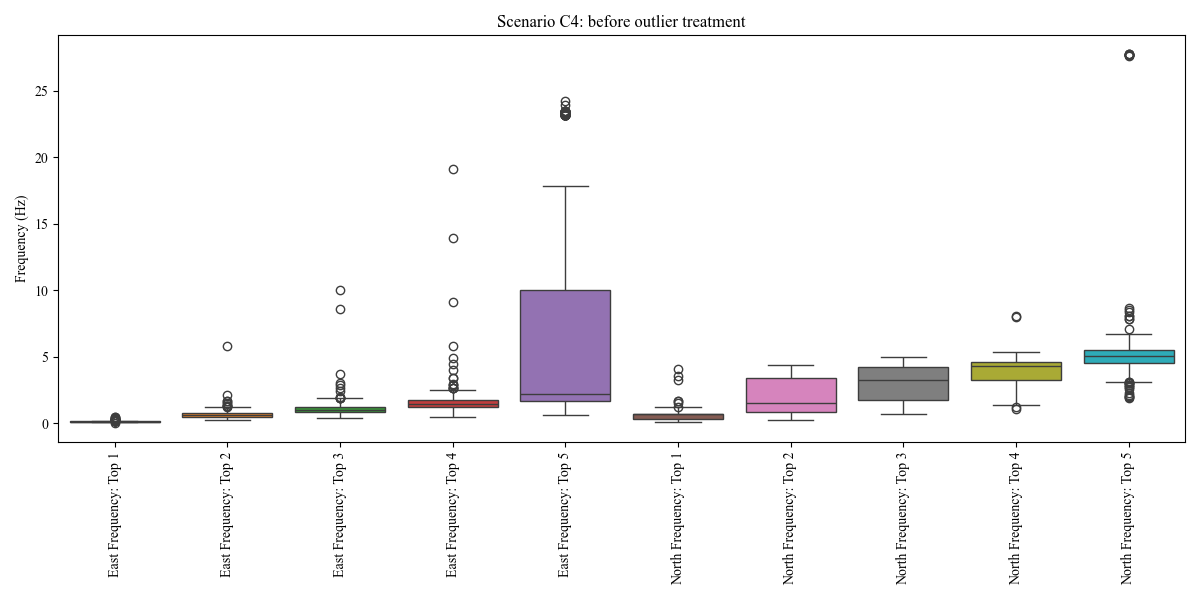

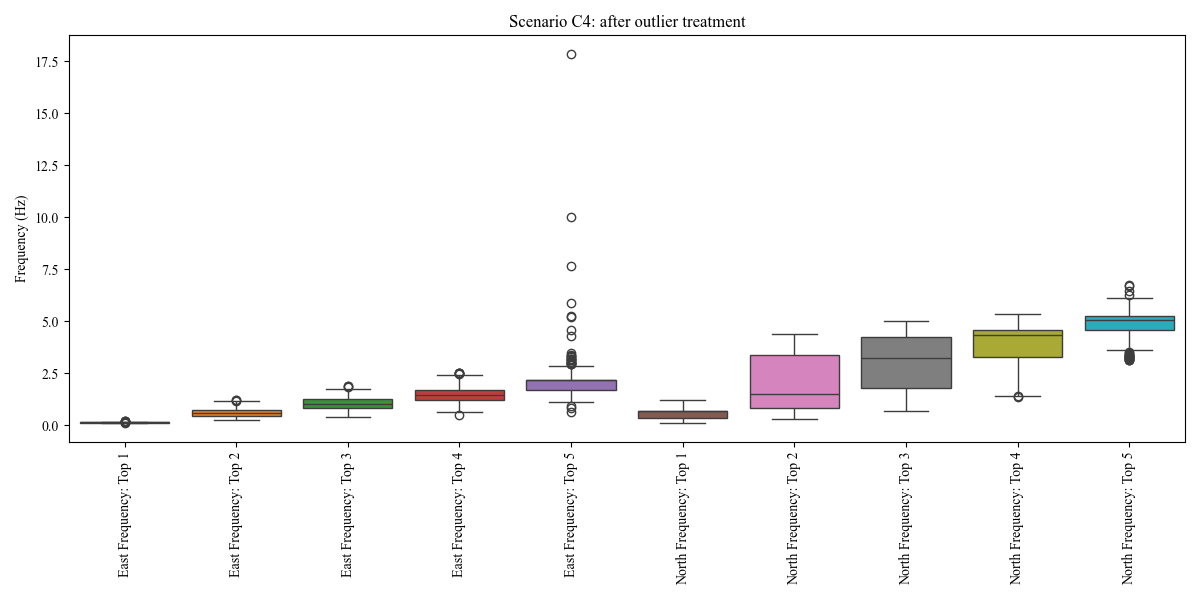

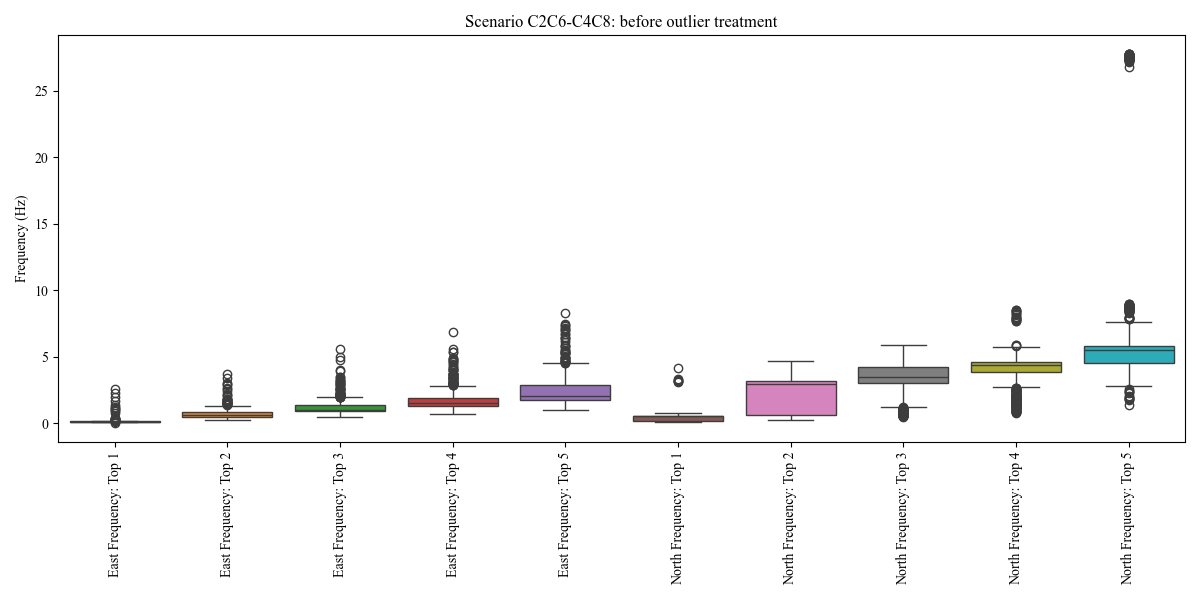

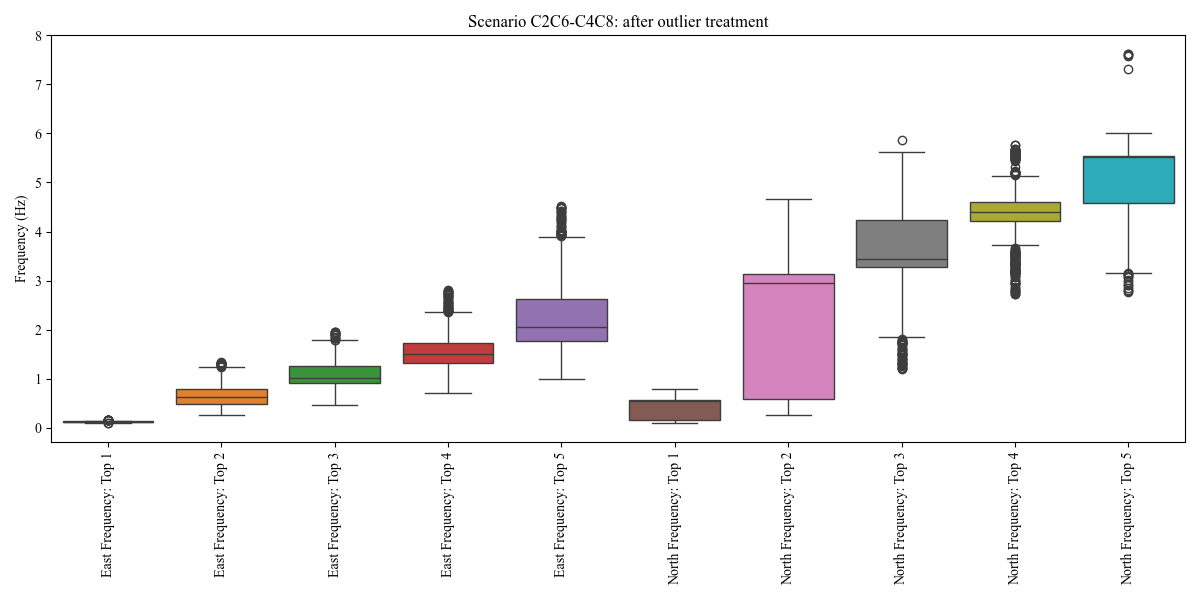

In [13]:
# Before/after boxplots for every damage scenario, with English display labels for
# the feature axes (the underlying column names keep the dataset's Spanish labels).
EN_LABELS = {f'Este Frecuency: Top {i}': f'East Frequency: Top {i}' for i in range(1, 6)}
EN_LABELS.update({f'Norte Frecuency: Top {i}': f'North Frequency: Top {i}' for i in range(1, 6)})

scenario_col = raw_data.iloc[:, 12]
scenarios = scenario_col.unique()

for scenario in scenarios:
    indices = scenario_col[scenario_col == scenario].index

    data_before = modal_data_before.loc[indices].rename(columns=EN_LABELS)
    data_after = modal_data.loc[indices].rename(columns=EN_LABELS)

    # Before treatment.
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data_before)
    plt.title(f"Scenario {scenario}: before outlier treatment")
    plt.ylabel("Frequency (Hz)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    # After treatment.
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data_after)
    plt.title(f"Scenario {scenario}: after outlier treatment")
    plt.ylabel("Frequency (Hz)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

Overall feature distributions before and after treatment (all scenarios pooled; some
apparent outliers remain because different modes overlap when pooled).

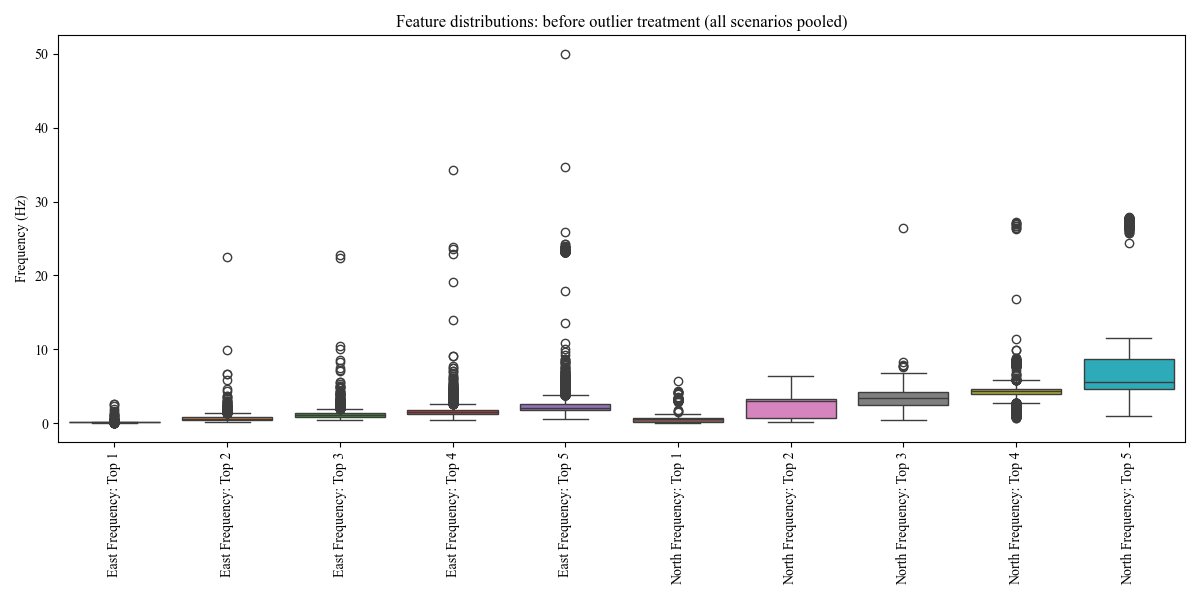

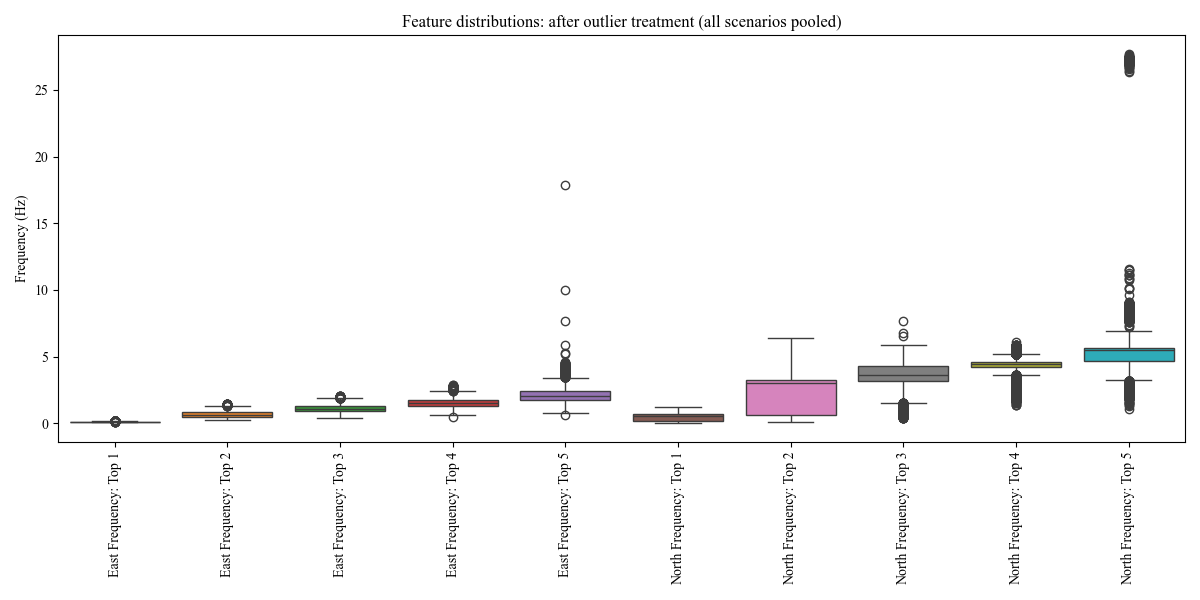

In [14]:
# Pooled distributions, before treatment.
plt.figure(figsize=(12, 6))
sns.boxplot(data=modal_data_before.rename(columns=EN_LABELS))
plt.title("Feature distributions: before outlier treatment (all scenarios pooled)")
plt.ylabel("Frequency (Hz)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Pooled distributions, after treatment.
plt.figure(figsize=(12, 6))
sns.boxplot(data=modal_data.rename(columns=EN_LABELS))
plt.title("Feature distributions: after outlier treatment (all scenarios pooled)")
plt.ylabel("Frequency (Hz)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Close-up comparison of a single feature before and after treatment.

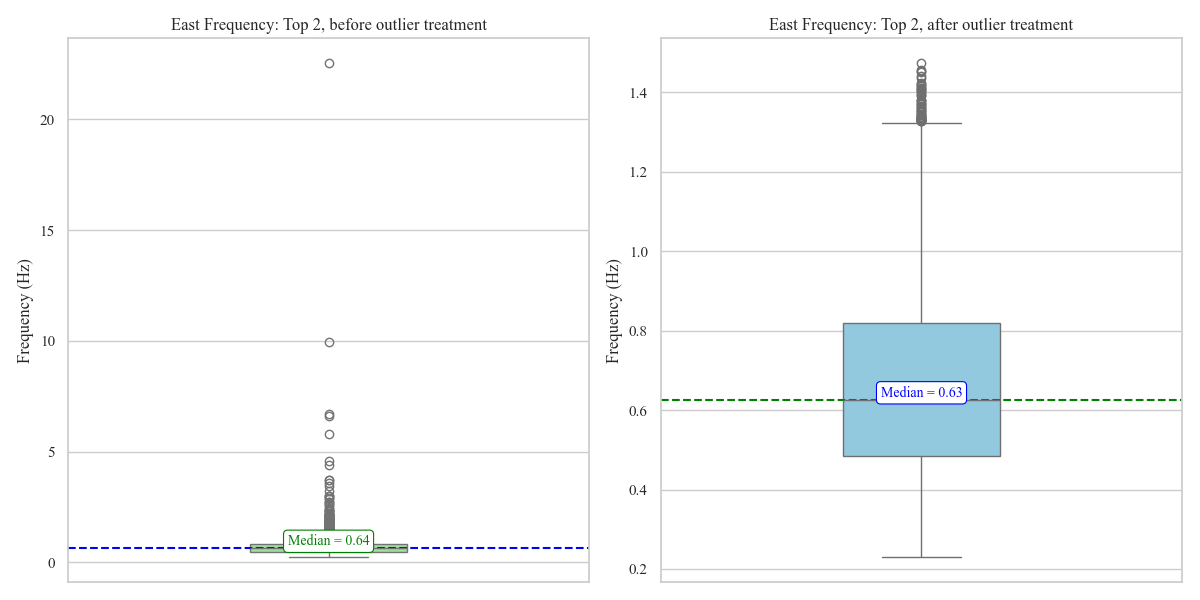

In [15]:
# Visual style (sns.set resets the font, so it is restored right after).
sns.set(style="whitegrid", palette="pastel")
mpl.rcParams['font.family'] = 'Times New Roman'

# Feature under comparison.
before = modal_data_before['Este Frecuency: Top 2'].dropna()
after = modal_data['Este Frecuency: Top 2'].dropna()

median_before = before.median()
median_after = after.median()

plt.figure(figsize=(12, 6))

# Before treatment.
plt.subplot(1, 2, 1)
sns.boxplot(y=before, color="lightgreen", width=0.3)
plt.title("East Frequency: Top 2, before outlier treatment")
plt.ylabel("Frequency (Hz)")
plt.axhline(median_before, color='blue', linestyle='--')
plt.text(0, median_before, f"Median = {median_before:.2f}",
         ha='center', va='bottom', fontsize=10, color='green',
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", lw=0.8))

# After treatment.
plt.subplot(1, 2, 2)
sns.boxplot(y=after, color="skyblue", width=0.3)
plt.title("East Frequency: Top 2, after outlier treatment")
plt.ylabel("Frequency (Hz)")
plt.axhline(median_after, color='green', linestyle='--')
plt.text(0, median_after, f"Median = {median_after:.2f}",
         ha='center', va='bottom', fontsize=10, color='blue',
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", lw=0.8))

plt.tight_layout()
plt.show()

Distribution of each frequency rank (Top 1 to Top 5) across the sensor axes, before and
after treatment.

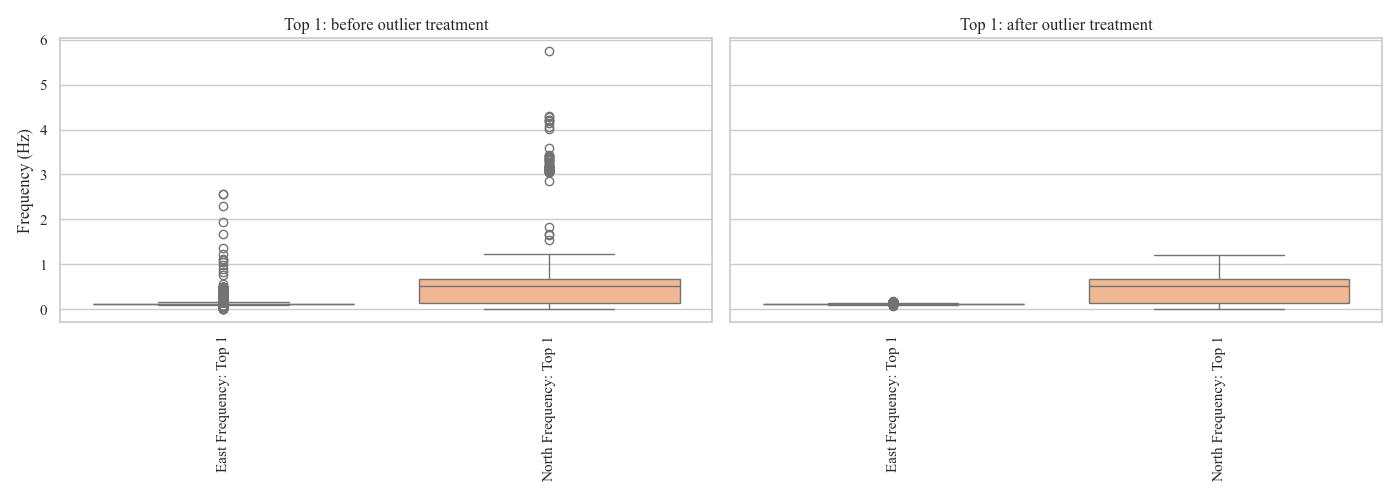

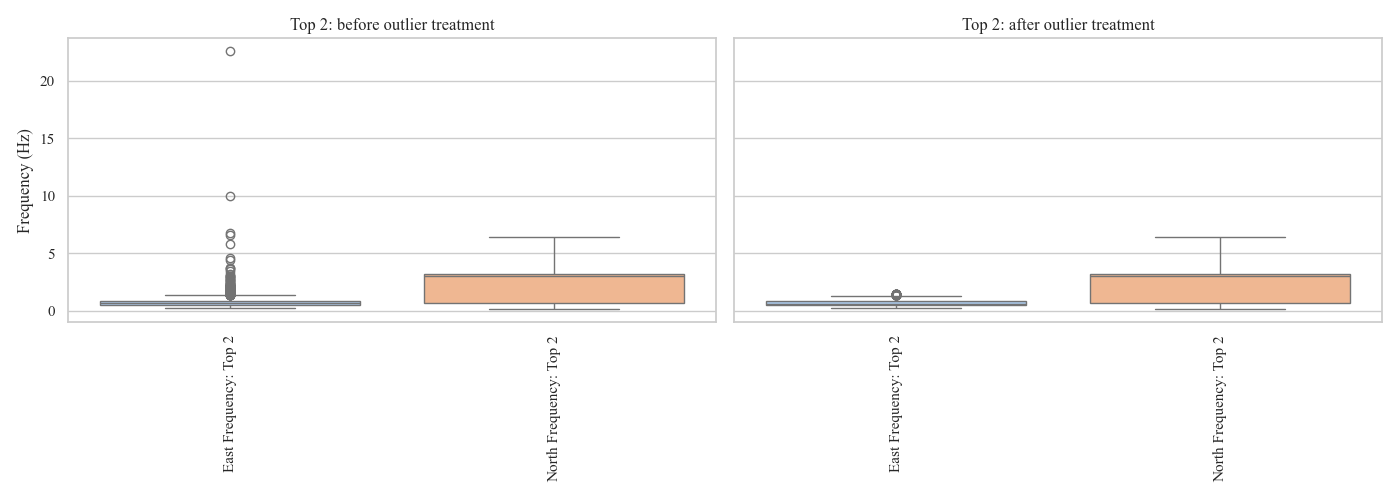

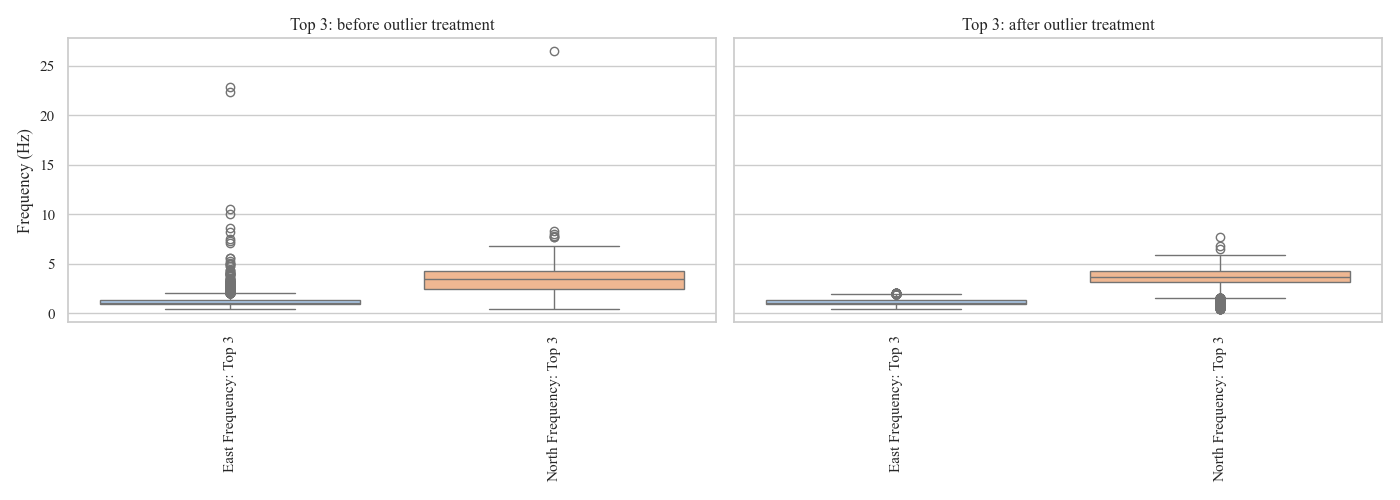

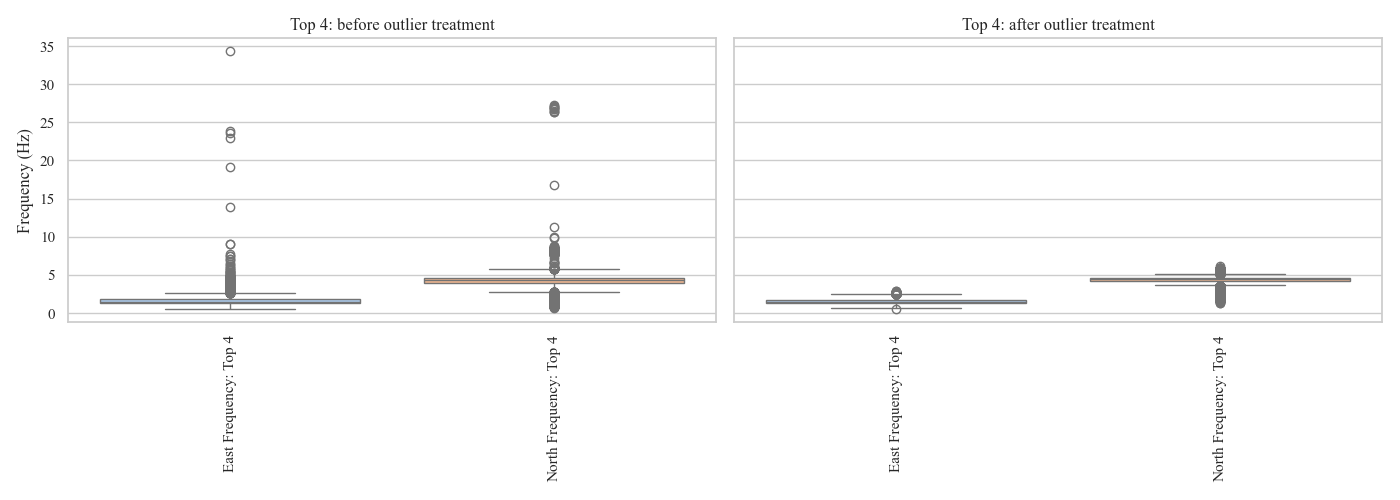

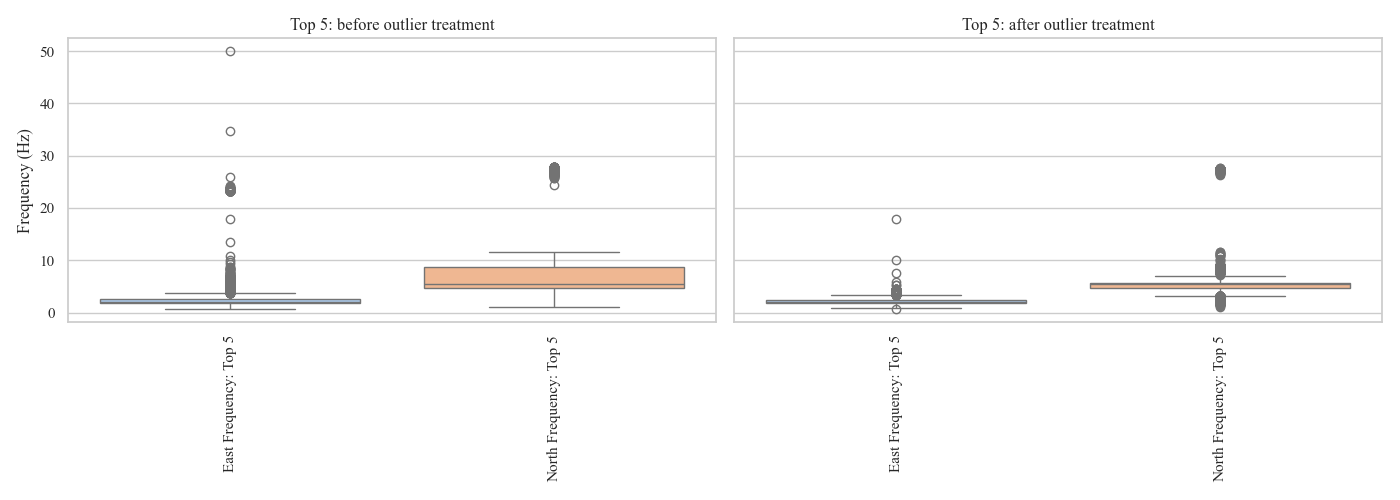

In [16]:
# Before/after distribution per frequency rank (Top 1 to Top 5).
for i in range(1, n_freq_peaks + 1):
    top_tag = f"Top {i}"

    # Columns of this rank across both axes.
    cols_top = [col for col in modal_data.columns if col.endswith(top_tag)]

    before = modal_data_before[cols_top].rename(columns=EN_LABELS)
    after = modal_data[cols_top].rename(columns=EN_LABELS)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    sns.boxplot(data=before, ax=axes[0])
    axes[0].set_title(f"Top {i}: before outlier treatment")
    axes[0].set_ylabel("Frequency (Hz)")
    axes[0].tick_params(axis='x', rotation=90)

    sns.boxplot(data=after, ax=axes[1])
    axes[1].set_title(f"Top {i}: after outlier treatment")
    axes[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

## 5.4 Normalization (delegated to the AutoML setup)

Manual Min-Max scaling, kept as a disabled reference. Normalization is instead applied
inside the PyCaret pipeline (`normalize=True, normalize_method='minmax'` in Section 6),
which guarantees the scaler is fitted on the training split only and packaged with the
deployable model.

In [17]:
# # 1. Split the modal features and the labels.
# modal_data = raw_data_No_Outliyers.iloc[:, :20].copy()
# labels = raw_data_No_Outliyers.iloc[:, 20:23].copy()

# # 2. Min-Max scale each feature column.
# scaler = MinMaxScaler()
# modal_data_scaled = pd.DataFrame(scaler.fit_transform(modal_data), columns=modal_data.columns)

# # 3. Reattach the labels.
# raw_data_normalized = pd.concat([modal_data_scaled, labels], axis=1)

# # 4. (Optional) inspect the result.
# print("Normalization complete.")
# display(raw_data_normalized.head())

## 5.5 Dataset assembly per classification task

In [18]:
# 1. Binary task: modal features + the healthy/damaged target.
Binary_data = pd.concat([
    raw_data_No_Outliyers.iloc[:, :10],           # modal-frequency features
    raw_data_No_Outliyers[["Categoría_Binaria"]]  # binary target
], axis=1)

# 2. Multiclass task: modal features + the damage-location target.
Multiclass_data = pd.concat([
    raw_data_No_Outliyers.iloc[:, :10],              # modal-frequency features
    raw_data_No_Outliyers[["Categoría_Multiclase"]]  # location target
], axis=1)

print("Datasets assembled.")
print("Binary_data shape:", Binary_data.shape)
print("Multiclass_data shape:", Multiclass_data.shape)

display(Binary_data.head())
display(Multiclass_data.head())

Datasets assembled.
Binary_data shape: (6888, 11)
Multiclass_data shape: (6888, 11)


,Este Frecuency: Top 1,Este Frecuency: Top 2,Este Frecuency: Top 3,Este Frecuency: Top 4,Este Frecuency: Top 5,Norte Frecuency: Top 1,Norte Frecuency: Top 2,Norte Frecuency: Top 3,Norte Frecuency: Top 4,Norte Frecuency: Top 5,Categoría_Binaria
0,0.107243,0.920291,1.351756,1.603651,2.172287,0.680866,1.294393,1.748304,3.566441,5.032921,damaged
1,0.127195,0.261872,0.379090,0.496309,0.618516,0.673384,2.035116,2.351856,2.638667,4.187450,damaged
2,0.114725,0.421488,1.227055,1.386672,1.586193,0.795591,2.553871,3.716081,4.471768,5.172586,damaged
3,0.127195,1.069932,1.022546,1.446528,4.284717,0.678372,1.032522,1.401636,4.372007,4.549082,damaged
4,0.134677,0.907821,1.082402,1.680966,2.301975,0.673384,1.020052,1.204609,2.169792,6.459497,damaged


,Este Frecuency: Top 1,Este Frecuency: Top 2,Este Frecuency: Top 3,Este Frecuency: Top 4,Este Frecuency: Top 5,Norte Frecuency: Top 1,Norte Frecuency: Top 2,Norte Frecuency: Top 3,Norte Frecuency: Top 4,Norte Frecuency: Top 5,Categoría_Multiclase
0,0.107243,0.920291,1.351756,1.603651,2.172287,0.680866,1.294393,1.748304,3.566441,5.032921,bottom
1,0.127195,0.261872,0.379090,0.496309,0.618516,0.673384,2.035116,2.351856,2.638667,4.187450,bottom
2,0.114725,0.421488,1.227055,1.386672,1.586193,0.795591,2.553871,3.716081,4.471768,5.172586,bottom
3,0.127195,1.069932,1.022546,1.446528,4.284717,0.678372,1.032522,1.401636,4.372007,4.549082,bottom
4,0.134677,0.907821,1.082402,1.680966,2.301975,0.673384,1.020052,1.204609,2.169792,6.459497,bottom


Optional label encoders (binary label-encoding / multiclass one-hot), kept disabled;
PyCaret encodes the target internally.

In [19]:
# from sklearn.preprocessing import LabelEncoder
# import pandas as pd

# # ---------- Binary task ----------
# binary_features = Binary_data.iloc[:, :20].copy()
# binary_labels = Binary_data["Categoría_Binaria"].copy()

# # Label-encode the binary target.
# le = LabelEncoder()
# binary_labels_encoded = le.fit_transform(binary_labels)
# Binary_data_encoded = pd.concat([binary_features, pd.Series(binary_labels_encoded, name="Categoría_Binaria_Encoded")], axis=1)

# # ---------- Multiclass task ----------
# multiclass_features = Multiclass_data.iloc[:, :20].copy()
# multiclass_labels = Multiclass_data["Categoría_Multiclase"].copy()

# # One-hot encode the location target.
# multiclass_labels_encoded = pd.get_dummies(multiclass_labels, prefix="Clase")
# Multiclass_data_encoded = pd.concat([multiclass_features, multiclass_labels_encoded], axis=1)

# # (Optional) inspect the result.
# print("Categorical encoding complete.")
# display(Binary_data_encoded.head())
# display(Multiclass_data_encoded.head())

# 6. Machine Learning Training

Shared experiment parameters, fixed across both tasks and all five algorithms so
results are directly comparable, including a fixed `session_id` for reproducibility.

In [20]:
session_id = 261   # fixed random seed: makes the whole experiment reproducible
train_size = 0.8   # stratified 80/20 train / hold-out split
fold = 10          # folds for cross-validation
n_iter = 20        # candidate configurations per hyperparameter search

## 6.1 Binary Classification: Damage Detection

### 6.1.1 Experiment setup

In [21]:
# PyCaret experiment setup: returns a ClassificationExperiment. All feature columns
# are numeric; the target is categorical and PyCaret label-encodes it internally.
clf1 = setup(
             # Data and target
             data = Binary_data,
             target = 'Categoría_Binaria',
             use_gpu = True,                                                                # GPU acceleration for compatible algorithms
             session_id = session_id,                                                       # fixed seed -> reproducible experiment

             # Data engineering inside the pipeline
             remove_outliers = False, outliers_method = 'iforest',                          # outliers already treated in Section 5.3
             normalize = True, normalize_method = 'minmax',                                 # Min-Max scaler fitted on the training split only
             train_size = train_size, data_split_shuffle = True, data_split_stratify = True,# stratified 80/20 split

             # Preprocessing
             preprocess = True,                                                             # let the pipeline handle imputation/encoding
             imputation_type = 'simple', numeric_imputation = 'drop',                       # acquisition should never produce nulls; drop if any
                                         categorical_imputation = 'drop',
             index = True,                                                                  # the table carries its own index

             # Cross-validation strategy
             fold_strategy = 'stratifiedkfold',                                             # class-stratified folds
             fold = fold,                                                                   # number of CV partitions

             # Display
             html= True, verbose = True, memory = True,                                     # progress display, information grid, caching
             )

,Description,Value
0,Session id,261
1,Target,Categoría_Binaria
2,Target type,Binary
3,Target mapping,"damaged: 0, healthy: 1"
4,Original data shape,"(6888, 11)"
5,Transformed data shape,"(6888, 11)"
6,Transformed train set shape,"(5510, 11)"
7,Transformed test set shape,"(1378, 11)"
8,Numeric features,10
9,Preprocess,True


In [22]:
# Compare the five candidate algorithms on mean 10-fold CV performance.
best_model = compare_models(
                            include = ['svm', 'knn','rf','gbc','lightgbm'],     # algorithms under study
                            round = 4,                                          # decimals in the score grid
                            sort = 'Accuracy',                                  # ranking metric
                            verbose = True                                      # show the score grid
                            )

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9176,0.9693,0.9176,0.9173,0.9173,0.7788,0.7791,0.5910
gbc,Gradient Boosting Classifier,0.9129,0.9640,0.9129,0.9118,0.9116,0.7611,0.7630,0.8210
rf,Random Forest Classifier,0.9114,0.9604,0.9114,0.9102,0.9102,0.7578,0.7592,0.2230
svm,SVM - Linear Kernel,0.7499,0.6796,0.7499,0.5624,0.6427,0.0000,0.0000,0.0440
knn,K Neighbors Classifier,0.7414,0.7375,0.7414,0.7252,0.7310,0.2609,0.2641,0.1070


### 6.1.2 Support Vector Machine (SVM)

Train the model with 10-fold cross-validation. Reporting both CV-train and
CV-validation scores makes bias/variance visible: a high train score with a low
validation score would indicate overfitting.

In [23]:
# Train the model. create_model() runs the same 10-fold CV used by compare_models(),
# but reports the per-fold metrics. return_train_score=True adds the CV-train scores
# next to the CV-validation scores to make any overfitting visible.
svm_trained = create_model(
                            'svm',
                            round = 4,
                            verbose = True,
                            return_train_score = True,
                            cross_validation = True)

Hyperparameter search (random grid, 20 iterations) optimizing accuracy.
`choose_better=True` guarantees the returned model is never worse than the untuned
one. The best parameters found are printed below.

In [24]:
# Random-grid hyperparameter search optimizing accuracy. choose_better=True returns
# the original model whenever tuning does not improve it.
svm_tuned = tune_model(
                        svm_trained,
                        n_iter = n_iter,           # candidate configurations
                        optimize = 'Accuracy',     # tuning metric
                        choose_better = True,      # never return a worse model
                        tuner_verbose = True,
                        verbose = True,
                        round = 4
                        )

# Best hyperparameters found
svm_tuned.get_params()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7514,0.4534,0.7514,0.5645,0.6447,0.0000,0.0000
1,0.7514,0.4419,0.7514,0.5645,0.6447,0.0000,0.0000
2,0.7495,0.4195,0.7495,0.5618,0.6422,0.0000,0.0000
3,0.7495,0.4173,0.7495,0.5618,0.6422,0.0000,0.0000
4,0.7495,0.3832,0.7495,0.5618,0.6422,0.0000,0.0000
5,0.7495,0.4471,0.7495,0.5618,0.6422,0.0000,0.0000
6,0.7495,0.4339,0.7495,0.5618,0.6422,0.0000,0.0000
7,0.7495,0.4139,0.7495,0.5618,0.6422,0.0000,0.0000
8,0.7495,0.4589,0.7495,0.5618,0.6422,0.0000,0.0000


Fitting 10 folds for each of 20 candidates, totalling 200 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


{'alpha': 0.0001,
 'average': False,
 'class_weight': None,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.001,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'optimal',
 'loss': 'hinge',
 'max_iter': 1000,
 'n_iter_no_change': 5,
 'n_jobs': -1,
 'penalty': 'l2',
 'power_t': 0.5,
 'random_state': 261,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

Hold-out performance: confusion matrix (row-normalized, then absolute counts):

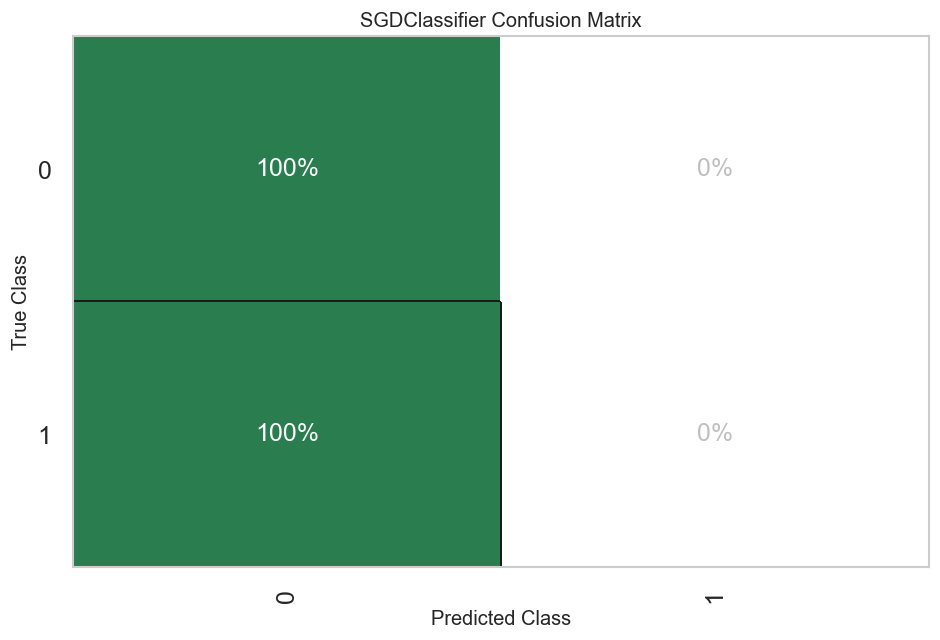

In [25]:
# Hold-out confusion matrix, row-normalized (share of each true class).
plot_model(
           svm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': True}
           )

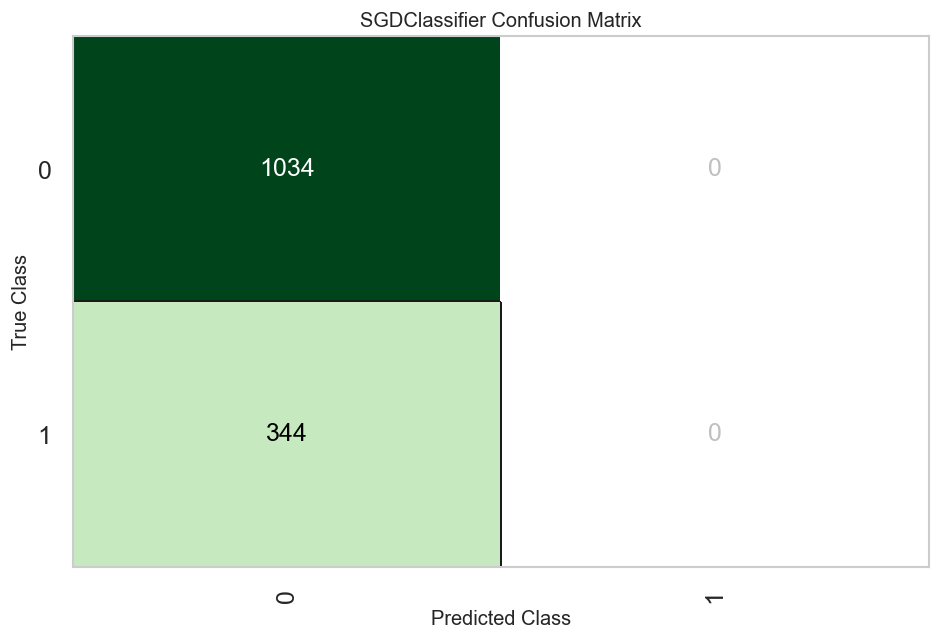

In [26]:
# Hold-out confusion matrix, absolute counts.
plot_model(
           svm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': False}
           )

Feature importance on the hold-out set, showing which natural frequencies drive the prediction:

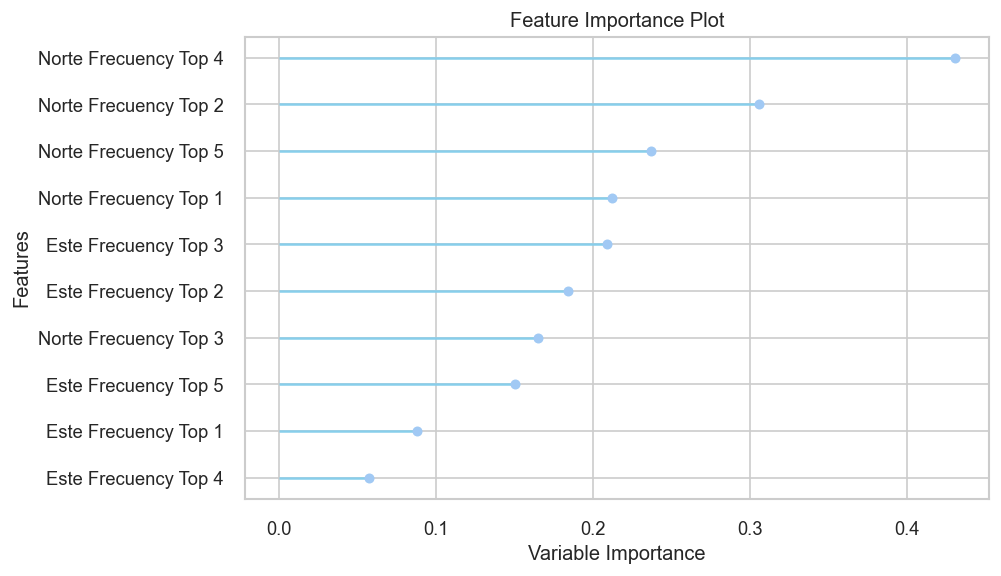

In [27]:
# Feature importance on the hold-out set.
plot_model(
           svm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'feature_all'
           )

The full deployable pipeline: every preprocessing step fitted during setup travels
with the model, so it can be applied to raw feature rows at inference time:

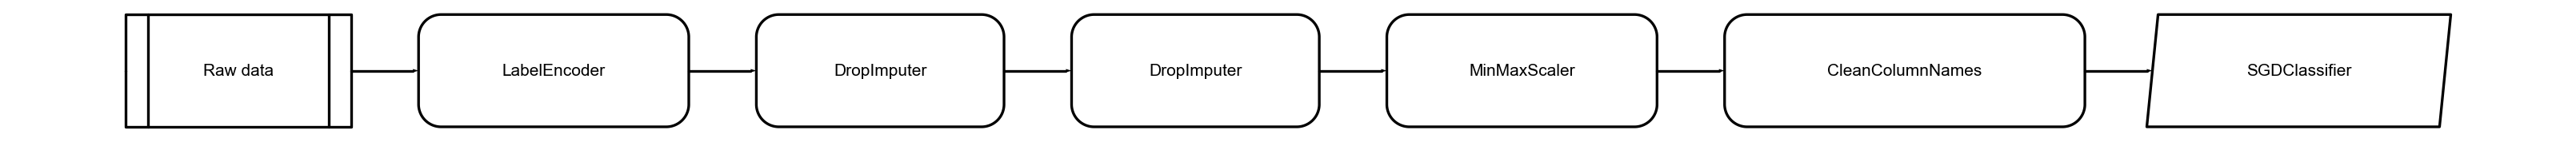

In [28]:
# The deployable pipeline: every preprocessing step fitted in setup() travels with the
# model and is applied automatically at inference time.
plot_model(
           svm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'pipeline'
           )

Interactive plot browser (renders only in a live session; static preview shows no output):

In [29]:
# Interactive plot browser (widget renders only in a live session).
evaluate_model(svm_tuned)

Persist the entire pipeline (preprocessing + model) as a pickle for deployment:

In [30]:
# Persist the full pipeline (preprocessing + model) as a pickle for deployment.
save_model(svm_tuned, str(save_path_Best_Model_Binary_SVM))

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=DropImputer(columns=['Este '
                                                                      'Frecuency: '
                                                                      'Top 1',
                                                                      'Este '
                                                                      'Frecuency: '
                                                                      'Top 2',
                                                                      'Este '
                                                                      'Frecuency: '
                      

Model interpretability: permutation feature importance on the hold-out set (SHAP tree
explainers do not apply to this estimator type; the interactive Plotly output does not
render in a static preview).

In [31]:
# Permutation feature importance on the hold-out set (interactive Plotly figure).
interpret_model(
                svm_tuned,
                plot = 'pfi',
                feature = '3Frecuency Top 1'   # only used by 'correlation'/'pdp' plots; ignored here
                )

### 6.1.3 K-Nearest Neighbors (KNN)

Train the model with 10-fold cross-validation. Reporting both CV-train and
CV-validation scores makes bias/variance visible: a high train score with a low
validation score would indicate overfitting.

In [32]:
# Train the model. create_model() runs the same 10-fold CV used by compare_models(),
# but reports the per-fold metrics. return_train_score=True adds the CV-train scores
# next to the CV-validation scores to make any overfitting visible.
knn_trained = create_model(
                            'knn',
                            round = 4,
                            verbose = True,
                            return_train_score = True,
                            cross_validation = True)

Hyperparameter search (random grid, 20 iterations) optimizing accuracy.
`choose_better=True` guarantees the returned model is never worse than the untuned
one. The best parameters found are printed below.

In [33]:
# Random-grid hyperparameter search optimizing accuracy. choose_better=True returns
# the original model whenever tuning does not improve it.
knn_tuned = tune_model(
                        knn_trained,
                        n_iter = n_iter,           # candidate configurations
                        optimize = 'Accuracy',     # tuning metric
                        choose_better = True,      # never return a worse model
                        tuner_verbose = True,
                        verbose = True,
                        round = 4
                        )

# Best hyperparameters found
knn_tuned.get_params()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8058,0.8392,0.8058,0.7943,0.7795,0.3713,0.4085
1,0.7967,0.8103,0.7967,0.7801,0.7720,0.3515,0.3803
2,0.7949,0.8591,0.7949,0.7836,0.7602,0.3170,0.3665
3,0.7804,0.8170,0.7804,0.7580,0.7534,0.3023,0.3278
4,0.7913,0.8449,0.7913,0.7758,0.7585,0.3132,0.3552
5,0.7985,0.8413,0.7985,0.7897,0.7644,0.3291,0.3804
6,0.7731,0.8319,0.7731,0.7485,0.7476,0.2875,0.3080
7,0.7750,0.8219,0.7750,0.7499,0.7443,0.2746,0.3028
8,0.7568,0.7680,0.7568,0.7260,0.7288,0.2340,0.2514


Fitting 10 folds for each of 20 candidates, totalling 200 fits


{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'manhattan',
 'metric_params': None,
 'n_jobs': -1,
 'n_neighbors': 27,
 'p': 2,
 'weights': 'distance'}

Hold-out performance: confusion matrix (row-normalized, then absolute counts):

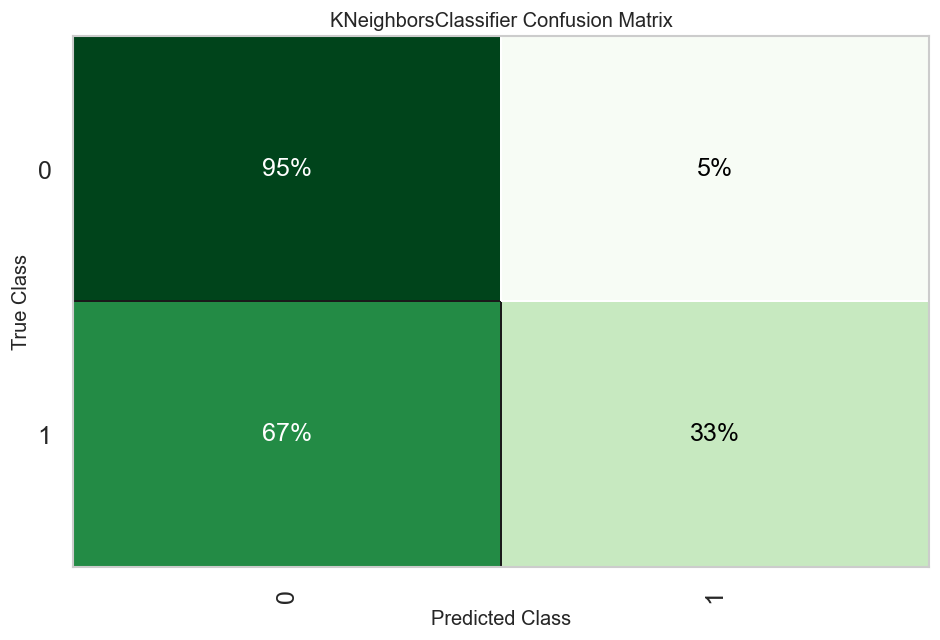

In [34]:
# Hold-out confusion matrix, row-normalized (share of each true class).
plot_model(
           knn_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': True}
           )

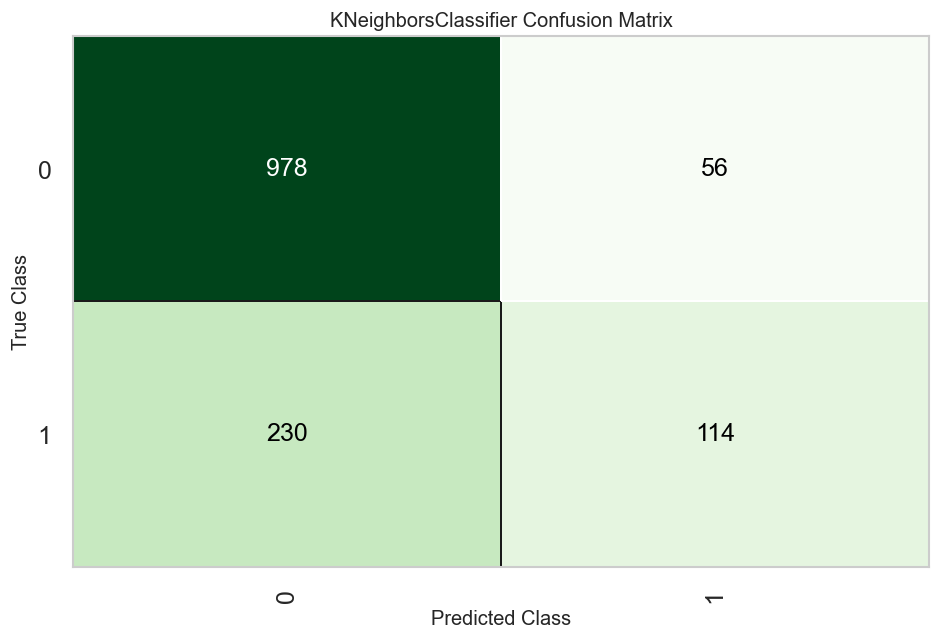

In [35]:
# Hold-out confusion matrix, absolute counts.
plot_model(
           knn_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': False}
           )

Per-class precision/recall/F1 on the hold-out set (KNN has no feature importances, so
the classification report is shown instead):

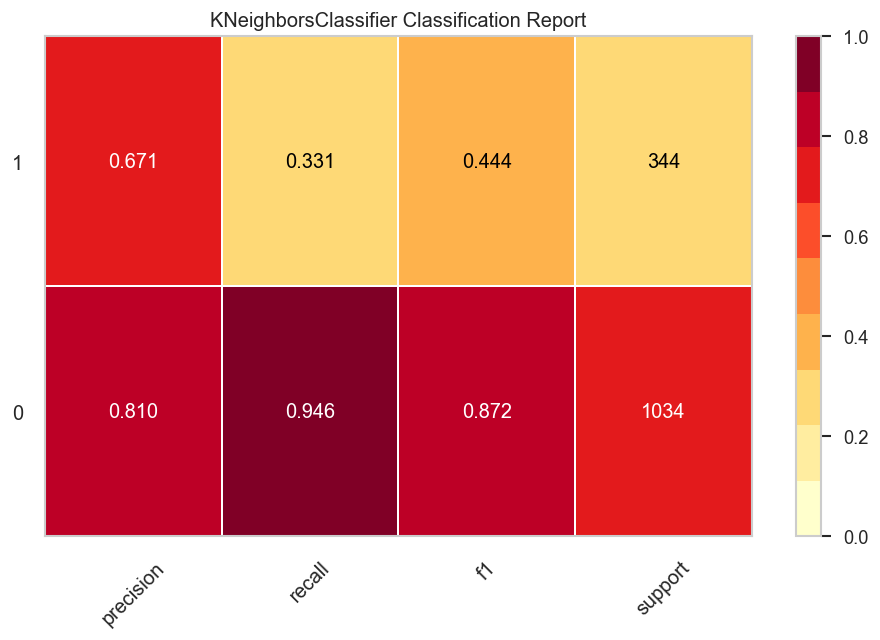

In [36]:
# Per-class precision / recall / F1 on the hold-out set.
plot_model(
           knn_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'class_report'
           )

The full deployable pipeline: every preprocessing step fitted during setup travels
with the model, so it can be applied to raw feature rows at inference time:

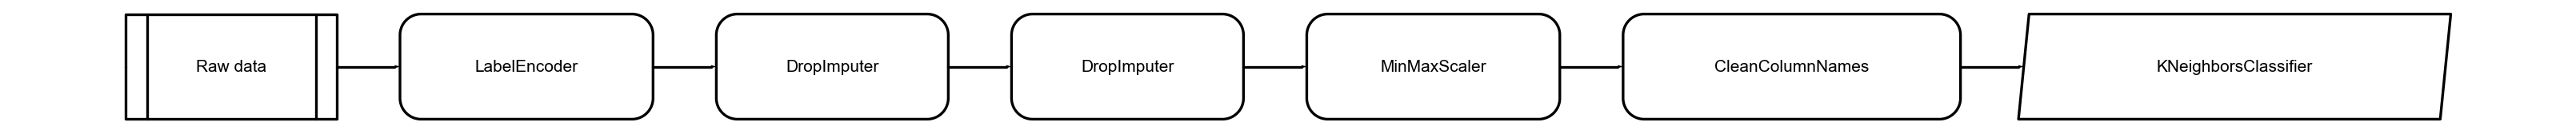

In [37]:
# The deployable pipeline: every preprocessing step fitted in setup() travels with the
# model and is applied automatically at inference time.
plot_model(
           knn_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'pipeline'
           )

Interactive plot browser (renders only in a live session; static preview shows no output):

In [38]:
# Interactive plot browser (widget renders only in a live session).
evaluate_model(knn_tuned)

Persist the entire pipeline (preprocessing + model) as a pickle for deployment:

In [39]:
# Persist the full pipeline (preprocessing + model) as a pickle for deployment.
save_model(knn_tuned, str(save_path_Best_Model_Binary_KNN))

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=DropImputer(columns=['Este '
                                                                      'Frecuency: '
                                                                      'Top 1',
                                                                      'Este '
                                                                      'Frecuency: '
                                                                      'Top 2',
                                                                      'Este '
                                                                      'Frecuency: '
                      

Model interpretability: permutation feature importance on the hold-out set (SHAP tree
explainers do not apply to this estimator type; the interactive Plotly output does not
render in a static preview).

In [40]:
# Permutation feature importance on the hold-out set (interactive Plotly figure).
interpret_model(
                knn_tuned,
                plot = 'pfi',
                feature = '3Frecuency Top 1'   # only used by 'correlation'/'pdp' plots; ignored here
                )

### 6.1.4 Random Forest

Train the model with 10-fold cross-validation. Reporting both CV-train and
CV-validation scores makes bias/variance visible: a high train score with a low
validation score would indicate overfitting.

In [41]:
# Train the model. create_model() runs the same 10-fold CV used by compare_models(),
# but reports the per-fold metrics. return_train_score=True adds the CV-train scores
# next to the CV-validation scores to make any overfitting visible.
rf_trained = create_model(
                            'rf',
                            round = 4,
                            verbose = True,
                            return_train_score = True,
                            cross_validation = True)

Hyperparameter search (random grid, 20 iterations) optimizing accuracy.
`choose_better=True` guarantees the returned model is never worse than the untuned
one. The best parameters found are printed below.

In [42]:
# Random-grid hyperparameter search optimizing accuracy. choose_better=True returns
# the original model whenever tuning does not improve it.
rf_tuned = tune_model(
                        rf_trained,
                        n_iter = n_iter,           # candidate configurations
                        optimize = 'Accuracy',     # tuning metric
                        choose_better = True,      # never return a worse model
                        tuner_verbose = True,
                        verbose = True,
                        round = 4
                        )

# Best hyperparameters found
rf_tuned.get_params()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9038,0.9651,0.9038,0.9020,0.9024,0.7355,0.7366
1,0.9147,0.9664,0.9147,0.9131,0.9127,0.7618,0.7647
2,0.9238,0.9710,0.9238,0.9226,0.9222,0.7888,0.7914
3,0.9111,0.9632,0.9111,0.9097,0.9101,0.7579,0.7586
4,0.9020,0.9568,0.9020,0.8998,0.8996,0.7271,0.7301
5,0.9165,0.9701,0.9165,0.9158,0.9137,0.7640,0.7698
6,0.9093,0.9517,0.9093,0.9093,0.9093,0.7583,0.7583
7,0.9056,0.9635,0.9056,0.9037,0.9039,0.7399,0.7417
8,0.8857,0.9375,0.8857,0.8828,0.8834,0.6840,0.6860


Fitting 10 folds for each of 20 candidates, totalling 200 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 261,
 'verbose': 0,
 'warm_start': False}

Hold-out performance: confusion matrix (row-normalized, then absolute counts):

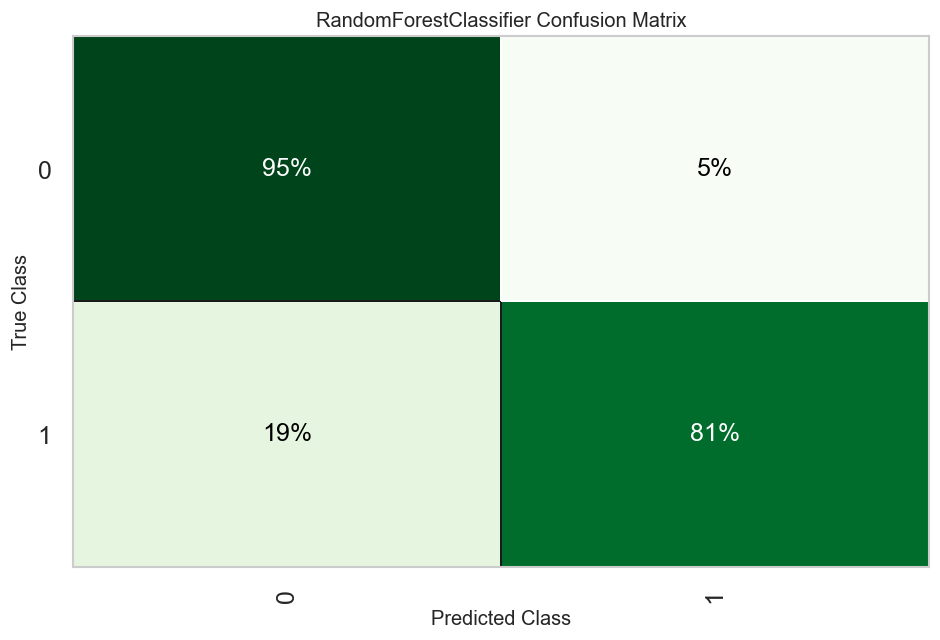

In [43]:
# Hold-out confusion matrix, row-normalized (share of each true class).
plot_model(
           rf_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': True}
           )

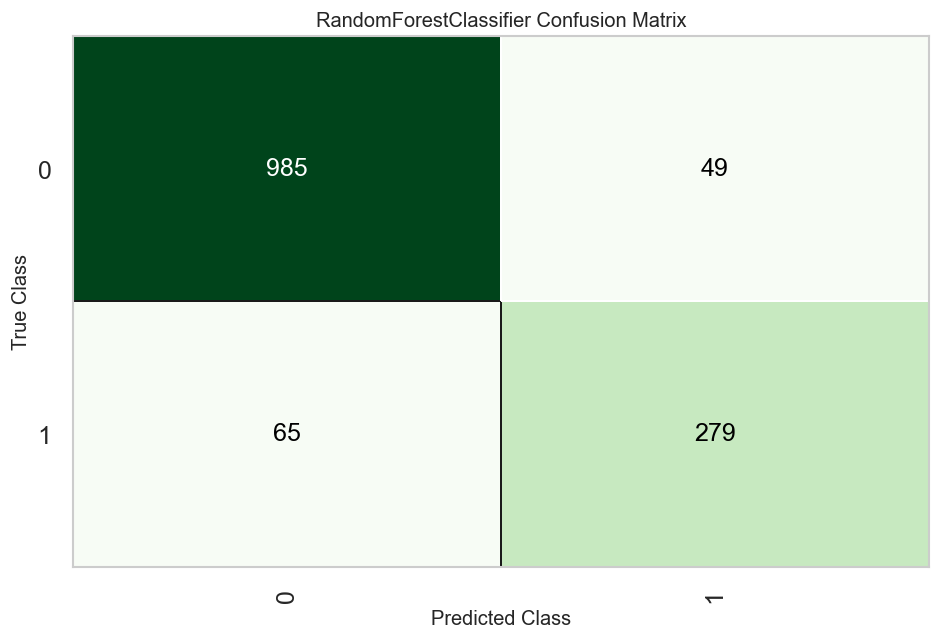

In [44]:
# Hold-out confusion matrix, absolute counts.
plot_model(
           rf_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': False}
           )

Feature importance on the hold-out set, showing which natural frequencies drive the prediction:

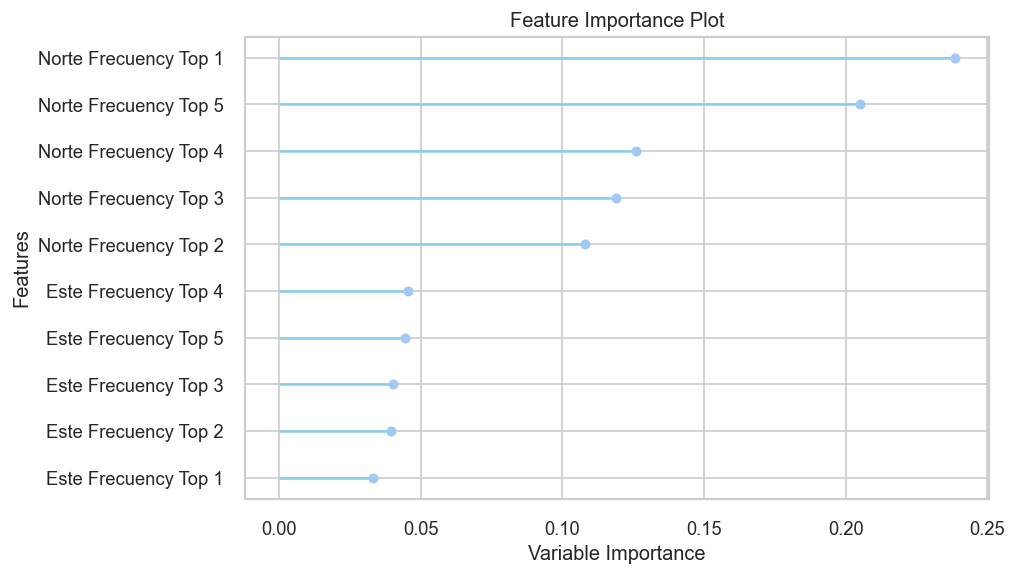

In [45]:
# Feature importance on the hold-out set.
plot_model(
           rf_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'feature_all'
           )

The full deployable pipeline: every preprocessing step fitted during setup travels
with the model, so it can be applied to raw feature rows at inference time:

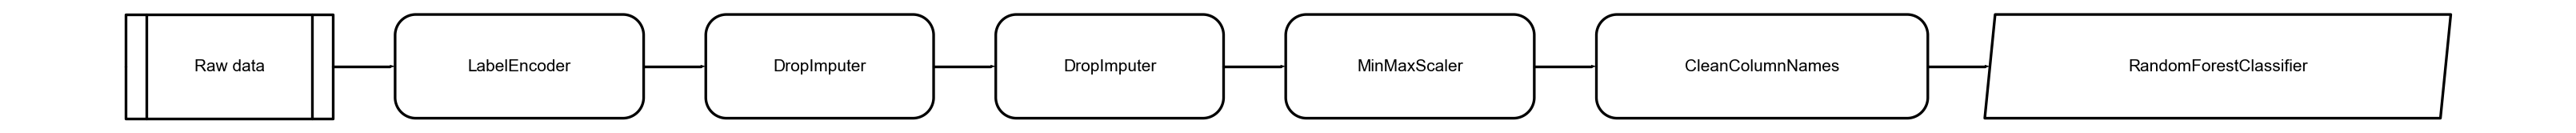

In [46]:
# The deployable pipeline: every preprocessing step fitted in setup() travels with the
# model and is applied automatically at inference time.
plot_model(
           rf_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'pipeline'
           )

Interactive plot browser (renders only in a live session; static preview shows no output):

In [47]:
# Interactive plot browser (widget renders only in a live session).
evaluate_model(rf_tuned)

Persist the entire pipeline (preprocessing + model) as a pickle for deployment:

In [48]:
# Persist the full pipeline (preprocessing + model) as a pickle for deployment.
save_model(rf_tuned, str(save_path_Best_Model_Binary_RF))

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=DropImputer(columns=['Este '
                                                                      'Frecuency: '
                                                                      'Top 1',
                                                                      'Este '
                                                                      'Frecuency: '
                                                                      'Top 2',
                                                                      'Este '
                                                                      'Frecuency: '
                      

Model interpretability: SHAP summary plot on the hold-out set: the contribution of
each natural frequency to individual predictions.

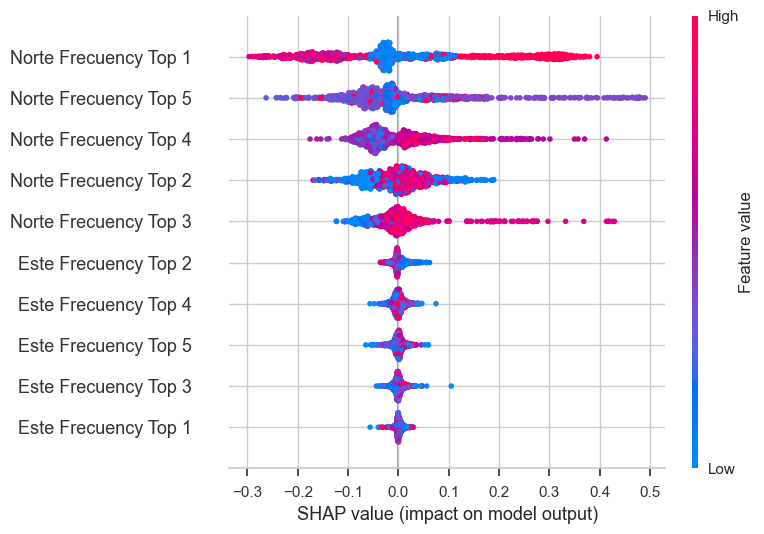

In [49]:
# SHAP summary plot on the hold-out set (TreeExplainer, tree-based models only).
interpret_model(
                rf_tuned,
                plot = 'summary',
                feature = '3Frecuency Top 1'   # only used by 'correlation'/'pdp' plots; ignored here
                )

### 6.1.5 Gradient Boosting

Train the model with 10-fold cross-validation. Reporting both CV-train and
CV-validation scores makes bias/variance visible: a high train score with a low
validation score would indicate overfitting.

In [50]:
# Train the model. create_model() runs the same 10-fold CV used by compare_models(),
# but reports the per-fold metrics. return_train_score=True adds the CV-train scores
# next to the CV-validation scores to make any overfitting visible.
gbc_trained = create_model(
                            'gbc',
                            round = 4,
                            verbose = True,
                            return_train_score = True,
                            cross_validation = True)

Hyperparameter search (random grid, 20 iterations) optimizing accuracy.
`choose_better=True` guarantees the returned model is never worse than the untuned
one. The best parameters found are printed below.

In [51]:
# Random-grid hyperparameter search optimizing accuracy. choose_better=True returns
# the original model whenever tuning does not improve it.
gbc_tuned = tune_model(
                        gbc_trained,
                        n_iter = n_iter,           # candidate configurations
                        optimize = 'Accuracy',     # tuning metric
                        choose_better = True,      # never return a worse model
                        tuner_verbose = True,
                        verbose = True,
                        round = 4
                        )

# Best hyperparameters found
gbc_tuned.get_params()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9147,0.9672,0.9147,0.9145,0.9146,0.7711,0.7712
1,0.9238,0.9681,0.9238,0.9226,0.9228,0.7909,0.7919
2,0.9292,0.9710,0.9292,0.9283,0.9278,0.8044,0.8067
3,0.9147,0.9704,0.9147,0.9154,0.9150,0.7744,0.7745
4,0.9056,0.9659,0.9056,0.9052,0.9054,0.7474,0.7475
5,0.9238,0.9718,0.9238,0.9227,0.9230,0.7930,0.7936
6,0.9093,0.9572,0.9093,0.9097,0.9095,0.7595,0.7595
7,0.9256,0.9759,0.9256,0.9245,0.9247,0.7974,0.7982
8,0.8966,0.9449,0.8966,0.8951,0.8956,0.7197,0.7202


Fitting 10 folds for each of 20 candidates, totalling 200 fits


{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.3,
 'loss': 'log_loss',
 'max_depth': 5,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.01,
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 80,
 'n_iter_no_change': None,
 'random_state': 261,
 'subsample': 0.95,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

Hold-out performance: confusion matrix (row-normalized, then absolute counts):

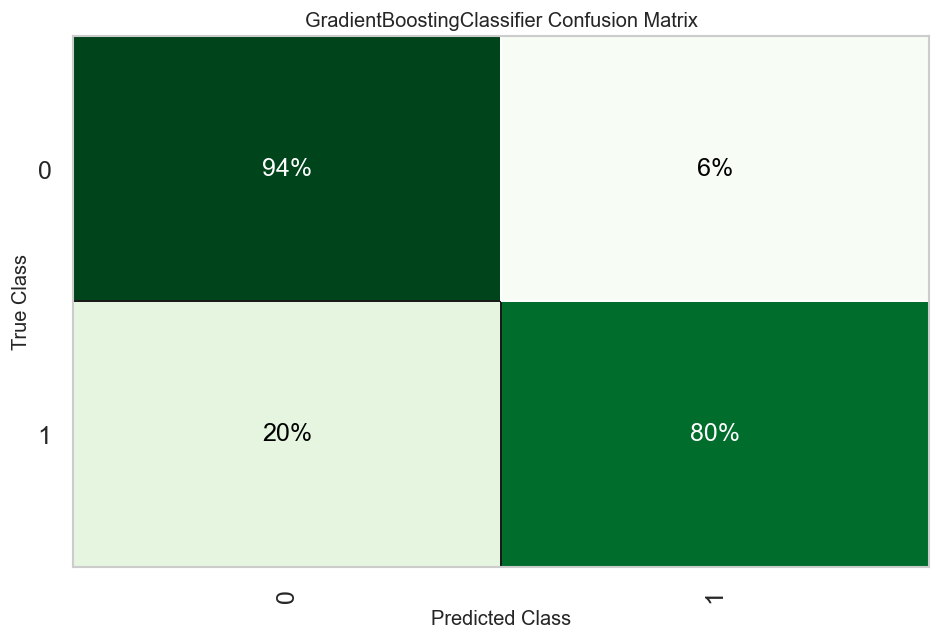

In [52]:
# Hold-out confusion matrix, row-normalized (share of each true class).
plot_model(
           gbc_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': True}
           )

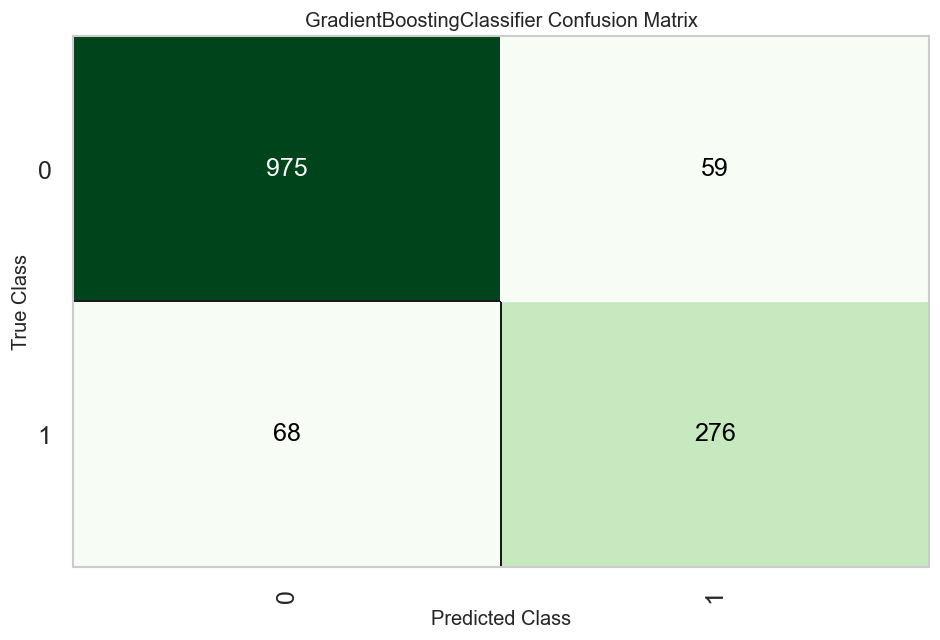

In [53]:
# Hold-out confusion matrix, absolute counts.
plot_model(
           gbc_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': False}
           )

Feature importance on the hold-out set, showing which natural frequencies drive the prediction:

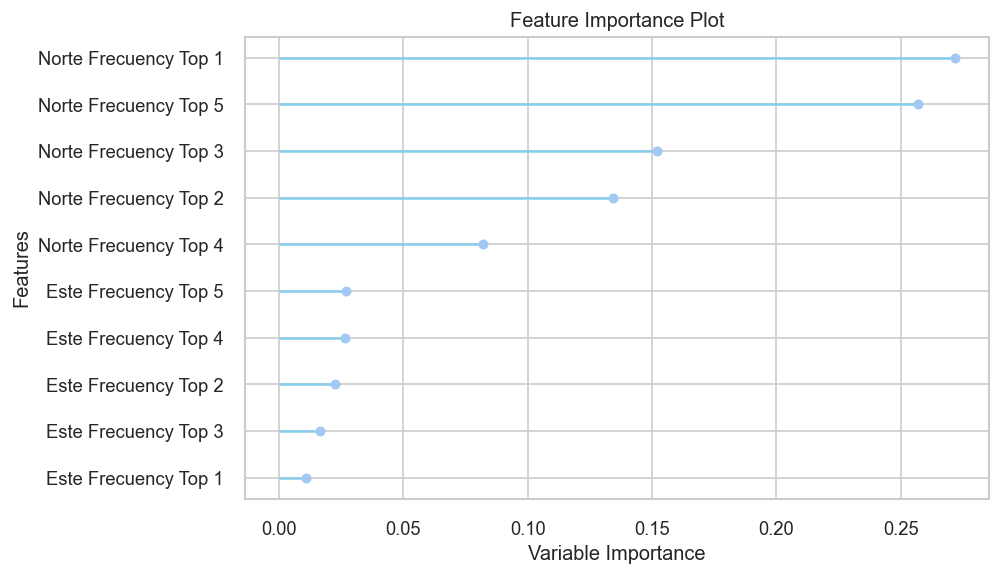

In [54]:
# Feature importance on the hold-out set.
plot_model(
           gbc_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'feature_all'
           )

The full deployable pipeline: every preprocessing step fitted during setup travels
with the model, so it can be applied to raw feature rows at inference time:

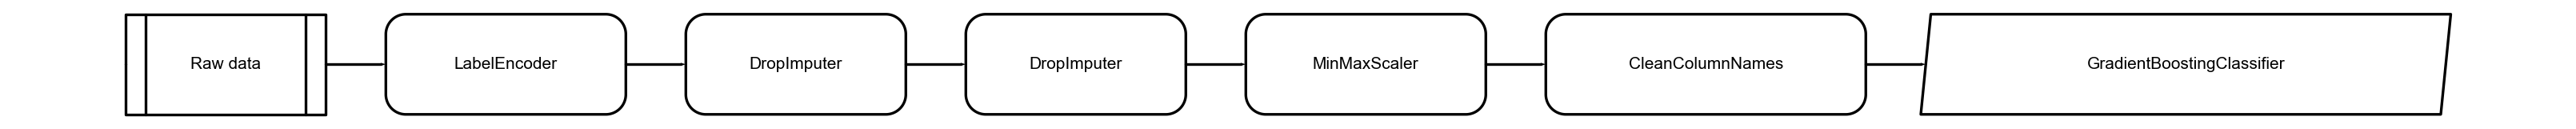

In [55]:
# The deployable pipeline: every preprocessing step fitted in setup() travels with the
# model and is applied automatically at inference time.
plot_model(
           gbc_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'pipeline'
           )

Interactive plot browser (renders only in a live session; static preview shows no output):

In [56]:
# Interactive plot browser (widget renders only in a live session).
evaluate_model(gbc_tuned)

Persist the entire pipeline (preprocessing + model) as a pickle for deployment:

In [57]:
# Persist the full pipeline (preprocessing + model) as a pickle for deployment.
save_model(gbc_tuned, str(save_path_Best_Model_Binary_GBC))

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=DropImputer(columns=['Este '
                                                                      'Frecuency: '
                                                                      'Top 1',
                                                                      'Este '
                                                                      'Frecuency: '
                                                                      'Top 2',
                                                                      'Este '
                                                                      'Frecuency: '
                      

Model interpretability: permutation feature importance on the hold-out set (SHAP tree
explainers do not apply to this estimator type; the interactive Plotly output does not
render in a static preview).

In [58]:
# Permutation feature importance on the hold-out set (interactive Plotly figure).
interpret_model(
                gbc_tuned,
                plot = 'pfi',
                feature = '3Frecuency Top 1'   # only used by 'correlation'/'pdp' plots; ignored here
                )

### 6.1.6 LightGBM

Train the model with 10-fold cross-validation. Reporting both CV-train and
CV-validation scores makes bias/variance visible: a high train score with a low
validation score would indicate overfitting.

In [59]:
# Train the model. create_model() runs the same 10-fold CV used by compare_models(),
# but reports the per-fold metrics. return_train_score=True adds the CV-train scores
# next to the CV-validation scores to make any overfitting visible.
lightgbm_trained = create_model(
                            'lightgbm',
                            round = 4,
                            verbose = True,
                            return_train_score = True,
                            cross_validation = True)

Hyperparameter search (random grid, 20 iterations) optimizing accuracy.
`choose_better=True` guarantees the returned model is never worse than the untuned
one. The best parameters found are printed below.

In [60]:
# Random-grid hyperparameter search optimizing accuracy. choose_better=True returns
# the original model whenever tuning does not improve it.
lightgbm_tuned = tune_model(
                        lightgbm_trained,
                        n_iter = n_iter,           # candidate configurations
                        optimize = 'Accuracy',     # tuning metric
                        choose_better = True,      # never return a worse model
                        tuner_verbose = True,
                        verbose = True,
                        round = 4
                        )

# Best hyperparameters found
lightgbm_tuned.get_params()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9256,0.9737,0.9256,0.9244,0.9245,0.7954,0.7966
1,0.9238,0.9665,0.9238,0.9225,0.9224,0.7888,0.7907
2,0.9238,0.9758,0.9238,0.9230,0.9217,0.7867,0.7908
3,0.9238,0.9739,0.9238,0.9238,0.9238,0.7970,0.7970
4,0.9074,0.9643,0.9074,0.9057,0.9048,0.7403,0.7446
5,0.9165,0.9798,0.9165,0.9158,0.9137,0.7640,0.7698
6,0.9165,0.9640,0.9165,0.9169,0.9167,0.7787,0.7787
7,0.9401,0.9777,0.9401,0.9395,0.9396,0.8377,0.8382
8,0.8947,0.9543,0.8947,0.8924,0.8928,0.7098,0.7116


Fitting 10 folds for each of 20 candidates, totalling 200 fits
[... 34314 lines of verbose training output truncated for readability ...]


{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.05,
 'max_depth': -1,
 'min_child_samples': 21,
 'min_child_weight': 0.001,
 'min_split_gain': 0.3,
 'n_estimators': 240,
 'n_jobs': -1,
 'num_leaves': 30,
 'objective': None,
 'random_state': 261,
 'reg_alpha': 0.001,
 'reg_lambda': 0.5,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'device': 'gpu',
 'feature_fraction': 0.4,
 'bagging_freq': 2,
 'bagging_fraction': 0.7}

Hold-out performance: confusion matrix (row-normalized, then absolute counts):

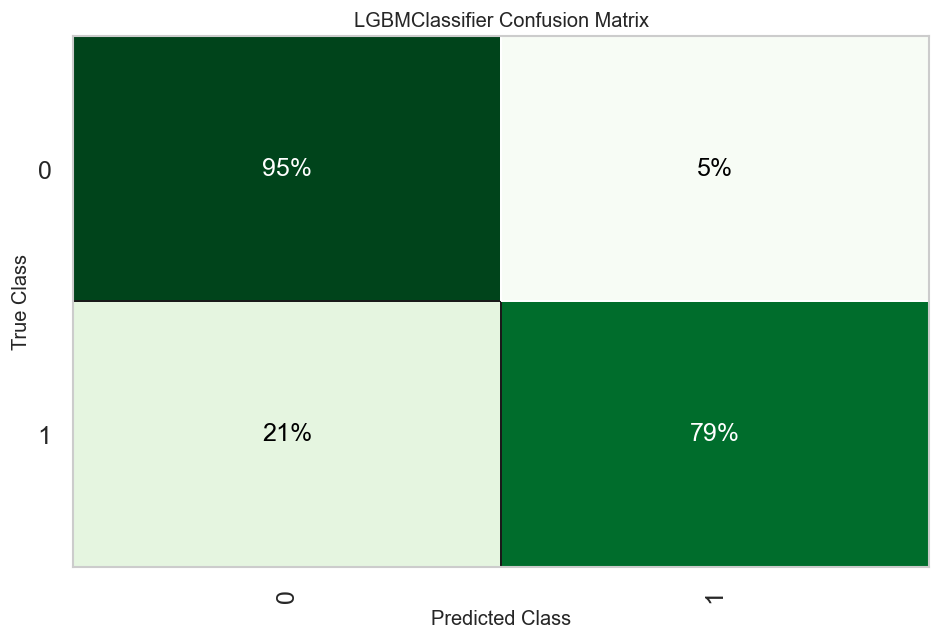

In [61]:
# Hold-out confusion matrix, row-normalized (share of each true class).
plot_model(
           lightgbm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': True}
           )

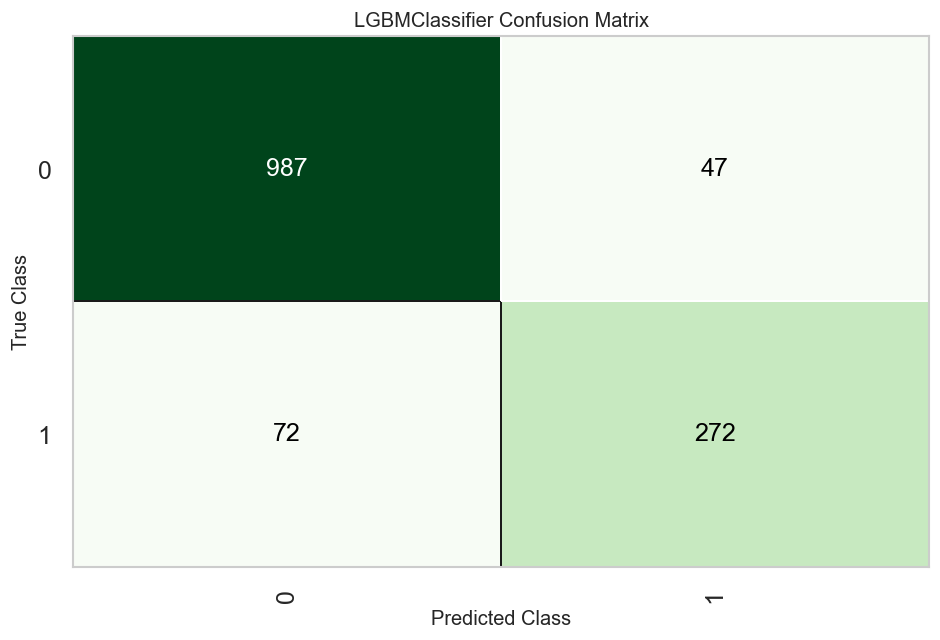

In [62]:
# Hold-out confusion matrix, absolute counts.
plot_model(
           lightgbm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': False}
           )

Feature importance on the hold-out set, showing which natural frequencies drive the prediction:

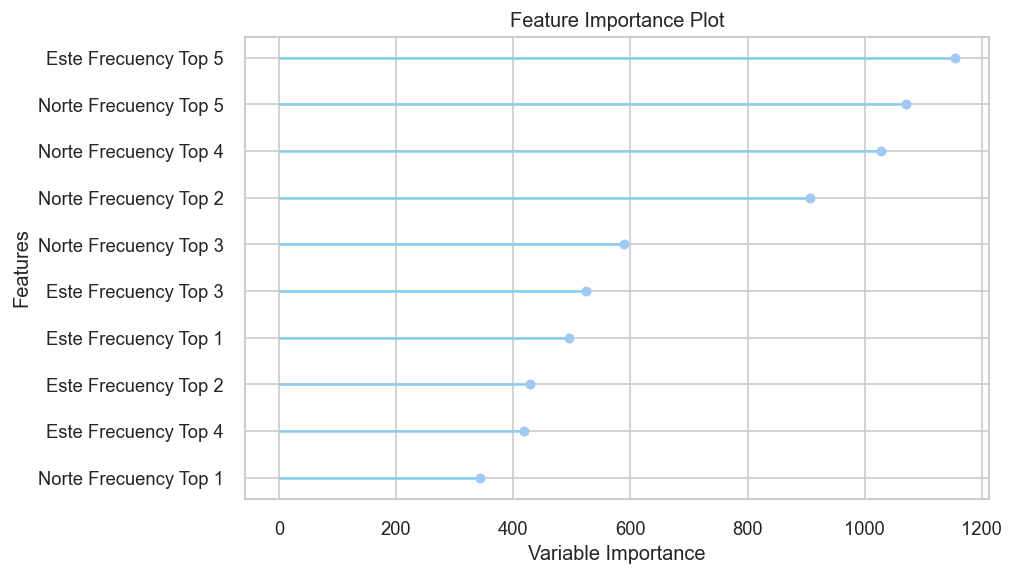

In [63]:
# Feature importance on the hold-out set.
plot_model(
           lightgbm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'feature_all'
           )

Model interpretability: SHAP summary plot on the hold-out set: the contribution of
each natural frequency to individual predictions.

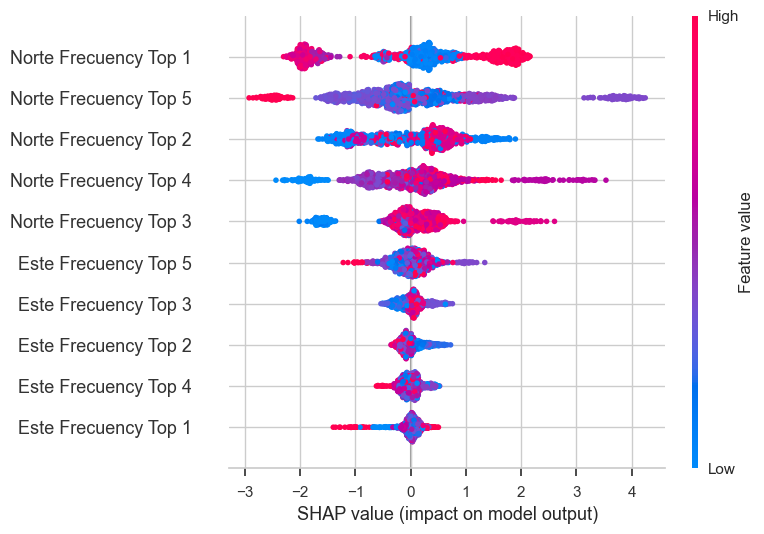

In [64]:
# SHAP summary plot on the hold-out set (TreeExplainer, tree-based models only).
interpret_model(
                lightgbm_tuned,
                plot = 'summary',
                feature = '3Frecuency Top 1'   # only used by 'correlation'/'pdp' plots; ignored here
                )

The full deployable pipeline: every preprocessing step fitted during setup travels
with the model, so it can be applied to raw feature rows at inference time:

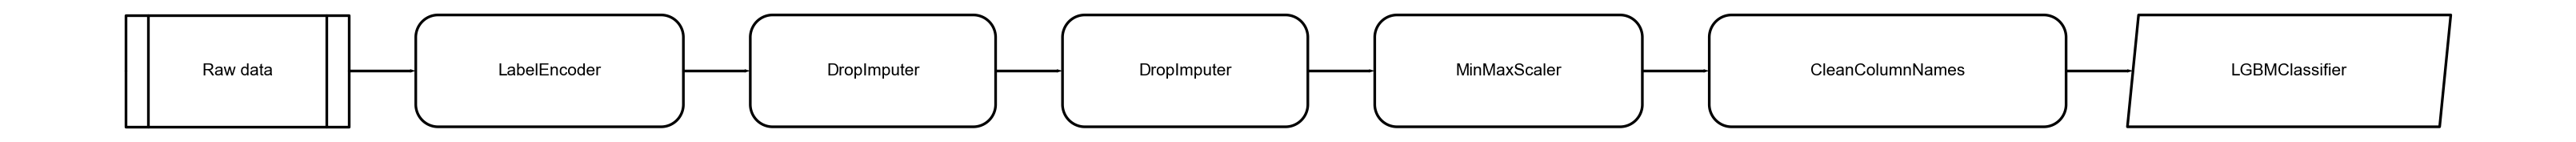

In [65]:
# The deployable pipeline: every preprocessing step fitted in setup() travels with the
# model and is applied automatically at inference time.
plot_model(
           lightgbm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'pipeline'
           )

Interactive plot browser (renders only in a live session; static preview shows no output):

In [66]:
# Interactive plot browser (widget renders only in a live session).
evaluate_model(lightgbm_tuned)

Persist the entire pipeline (preprocessing + model) as a pickle for deployment:

In [67]:
# Persist the full pipeline (preprocessing + model) as a pickle for deployment.
save_model(lightgbm_tuned, str(save_path_Best_Model_Binary_LightGBM))

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=DropImputer(columns=['Este '
                                                                      'Frecuency: '
                                                                      'Top 1',
                                                                      'Este '
                                                                      'Frecuency: '
                                                                      'Top 2',
                                                                      'Este '
                                                                      'Frecuency: '
                      

### 6.1.7 Model comparison on the hold-out set

Final evaluation: every tuned model predicts the hold-out split (20% of the data,
stratified, never seen during training or tuning). These are the headline results.

In [68]:
# Predict the hold-out split with every tuned model. With data=None, predict_model()
# scores the hold-out set automatically and prints the metrics per model.
pred_holdout_svm = predict_model(estimator = svm_tuned,
                             data = None,
                             )
pred_holdout_knn = predict_model(estimator = knn_tuned,
                             data = None,
                             )
pred_holdout_rf = predict_model(estimator = rf_tuned,
                             data = None,
                             )
pred_holdout_gbc = predict_model(estimator = gbc_tuned,
                             data = None,
                             )
pred_holdout_lightgbm = predict_model(estimator = lightgbm_tuned,
                             data = None,
                             )

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,SVM - Linear Kernel,0.7504,0,0.7504,0.5630,0.6433,0.0000,0.0000


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.7925,0.8315,0.7925,0.7749,0.7654,0.3335,0.3649


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9173,0.9638,0.9173,0.9163,0.9166,0.7757,0.7761


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.9078,0.9664,0.9078,0.9071,0.9074,0.7518,0.7519


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9136,0.9731,0.9136,0.9122,0.9125,0.7638,0.7647


## 6.2 Multiclass Classification: Damage Localization

### 6.2.1 Experiment setup

In [69]:
# PyCaret experiment setup: returns a ClassificationExperiment. All feature columns
# are numeric; the target is categorical and PyCaret label-encodes it internally.
clf1 = setup(
             # Data and target
             data = Multiclass_data,
             target = 'Categoría_Multiclase',
             use_gpu = True,                                                                # GPU acceleration for compatible algorithms
             session_id = session_id,                                                       # fixed seed -> reproducible experiment

             # Data engineering inside the pipeline
             remove_outliers = False, outliers_method = 'iforest',                          # outliers already treated in Section 5.3
             normalize = True, normalize_method = 'minmax',                                 # Min-Max scaler fitted on the training split only
             train_size = train_size, data_split_shuffle = True, data_split_stratify = True,# stratified 80/20 split

             # Preprocessing
             preprocess = True,                                                             # let the pipeline handle imputation/encoding
             imputation_type = 'simple', numeric_imputation = 'drop',                       # acquisition should never produce nulls; drop if any
                                         categorical_imputation = 'drop',
             index = True,                                                                  # the table carries its own index

             # Cross-validation strategy
             fold_strategy = 'stratifiedkfold',                                             # class-stratified folds
             fold = fold,                                                                   # number of CV partitions

             # Display
             html= True, verbose = True, memory = True,                                     # progress display, information grid, caching
             )

,Description,Value
0,Session id,261
1,Target,Categoría_Multiclase
2,Target type,Multiclass
3,Target mapping,"bottom: 0, healthy: 1, top: 2, top-bottom: 3"
4,Original data shape,"(6888, 11)"
5,Transformed data shape,"(6888, 11)"
6,Transformed train set shape,"(5510, 11)"
7,Transformed test set shape,"(1378, 11)"
8,Numeric features,10
9,Preprocess,True


In [70]:
# Compare the five candidate algorithms on mean 10-fold CV performance.
best_model = compare_models(
                            include = ['svm', 'knn','rf','gbc','lightgbm'],     # algorithms under study
                            round = 4,                                          # decimals in the score grid
                            sort = 'Accuracy',                                  # ranking metric
                            verbose = True                                      # show the score grid
                            )

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8492,0.9680,0.8492,0.8515,0.8496,0.7989,0.7993,1.7360
gbc,Gradient Boosting Classifier,0.8354,0.0000,0.8354,0.8377,0.8361,0.7805,0.7808,3.2060
rf,Random Forest Classifier,0.8250,0.9533,0.8250,0.8273,0.8255,0.7667,0.7671,0.2390
knn,K Neighbors Classifier,0.4537,0.7263,0.4537,0.4689,0.4540,0.2716,0.2745,0.1030
svm,SVM - Linear Kernel,0.3797,0.0000,0.3797,0.4328,0.3317,0.1727,0.1970,0.0670


### 6.2.2 Support Vector Machine (SVM)

Train the model with 10-fold cross-validation. Reporting both CV-train and
CV-validation scores makes bias/variance visible: a high train score with a low
validation score would indicate overfitting.

In [71]:
# Train the model. create_model() runs the same 10-fold CV used by compare_models(),
# but reports the per-fold metrics. return_train_score=True adds the CV-train scores
# next to the CV-validation scores to make any overfitting visible.
svm_trained = create_model(
                            'svm',
                            round = 4,
                            verbose = True,
                            return_train_score = True,
                            cross_validation = True)

Hyperparameter search (random grid, 20 iterations) optimizing accuracy.
`choose_better=True` guarantees the returned model is never worse than the untuned
one. The best parameters found are printed below.

In [72]:
# Random-grid hyperparameter search optimizing accuracy. choose_better=True returns
# the original model whenever tuning does not improve it.
svm_tuned = tune_model(
                        svm_trained,
                        n_iter = n_iter,           # candidate configurations
                        optimize = 'Accuracy',     # tuning metric
                        choose_better = True,      # never return a worse model
                        tuner_verbose = True,
                        verbose = True,
                        round = 4
                        )

# Best hyperparameters found
svm_tuned.get_params()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4211,0.0000,0.4211,0.4094,0.3937,0.2283,0.2365
1,0.3993,0.0000,0.3993,0.4496,0.3754,0.1992,0.2086
2,0.4047,0.0000,0.4047,0.4025,0.3739,0.2066,0.2159
3,0.3920,0.0000,0.3920,0.4670,0.3523,0.1897,0.2025
4,0.4192,0.0000,0.4192,0.4668,0.3688,0.2262,0.2533
5,0.4138,0.0000,0.4138,0.4276,0.3956,0.2183,0.2285
6,0.4011,0.0000,0.4011,0.4004,0.3907,0.2014,0.2045
7,0.3684,0.0000,0.3684,0.3571,0.3585,0.1579,0.1591
8,0.4011,0.0000,0.4011,0.3786,0.3796,0.2014,0.2057


Fitting 10 folds for each of 20 candidates, totalling 200 fits


{'alpha': 0.02,
 'average': False,
 'class_weight': None,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.01,
 'fit_intercept': True,
 'l1_ratio': 0.7000000001,
 'learning_rate': 'optimal',
 'loss': 'hinge',
 'max_iter': 1000,
 'n_iter_no_change': 5,
 'n_jobs': -1,
 'penalty': 'l2',
 'power_t': 0.5,
 'random_state': 261,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

Hold-out performance: confusion matrix (row-normalized, then absolute counts):

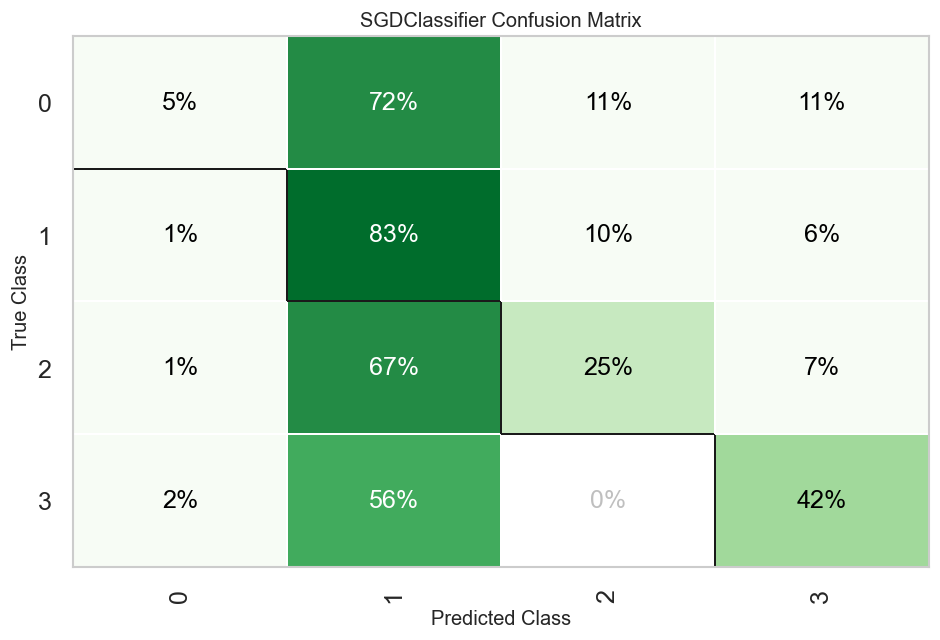

In [73]:
# Hold-out confusion matrix, row-normalized (share of each true class).
plot_model(
           svm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': True}
           )

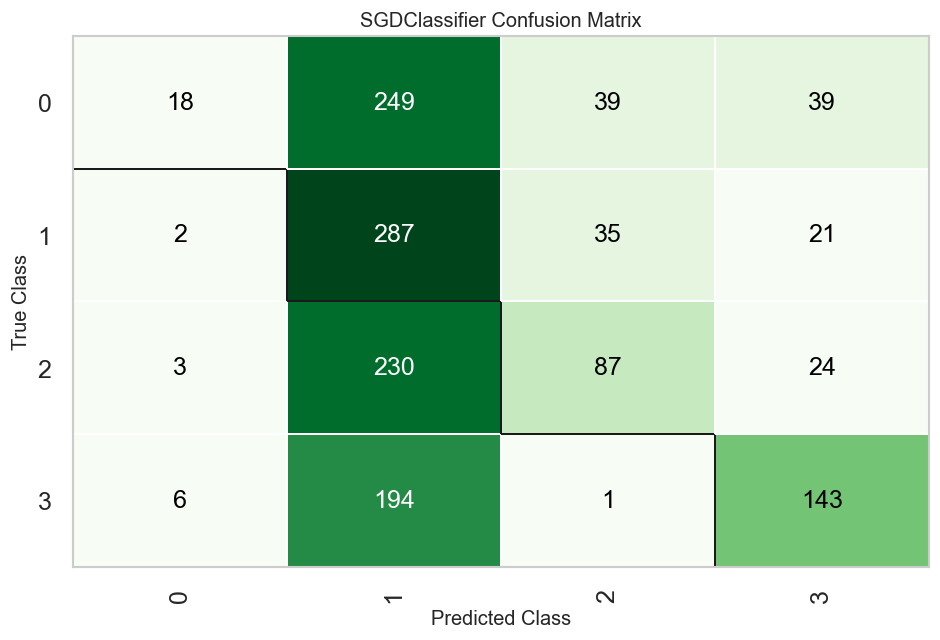

In [74]:
# Hold-out confusion matrix, absolute counts.
plot_model(
           svm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': False}
           )

Feature importance on the hold-out set, showing which natural frequencies drive the prediction:

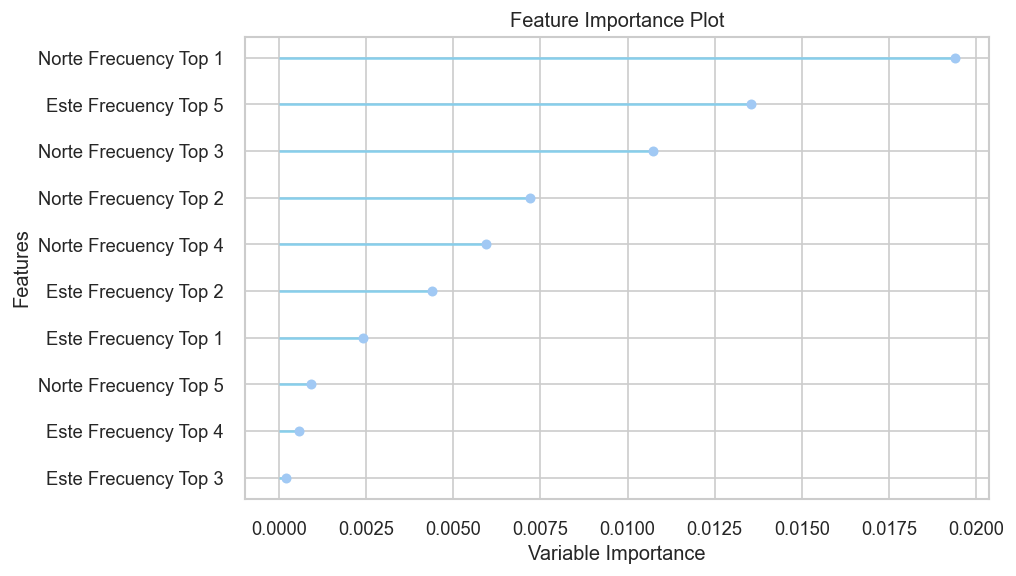

In [75]:
# Feature importance on the hold-out set.
plot_model(
           svm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'feature_all'
           )

The full deployable pipeline: every preprocessing step fitted during setup travels
with the model, so it can be applied to raw feature rows at inference time:

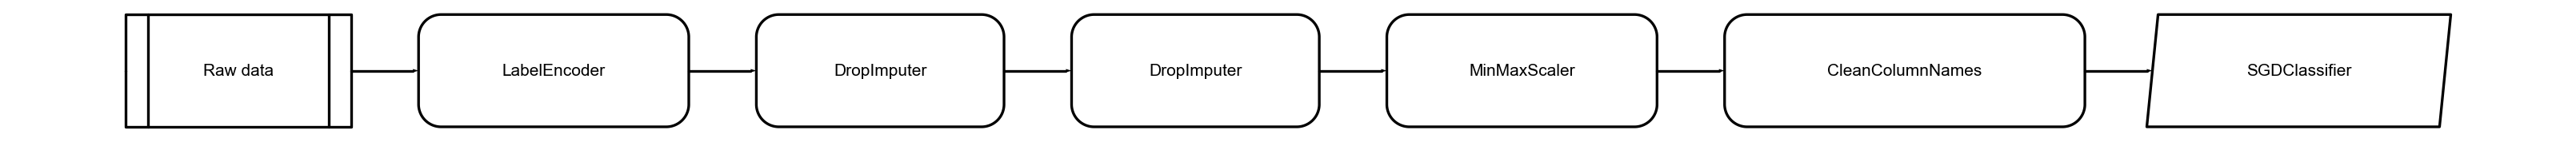

In [76]:
# The deployable pipeline: every preprocessing step fitted in setup() travels with the
# model and is applied automatically at inference time.
plot_model(
           svm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'pipeline'
           )

Interactive plot browser (renders only in a live session; static preview shows no output):

In [77]:
# Interactive plot browser (widget renders only in a live session).
evaluate_model(svm_tuned)

Persist the entire pipeline (preprocessing + model) as a pickle for deployment:

In [78]:
# Persist the full pipeline (preprocessing + model) as a pickle for deployment.
save_model(svm_tuned, str(save_path_Best_Model_Multiclass_SVM))

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=DropImputer(columns=['Este '
                                                                      'Frecuency: '
                                                                      'Top 1',
                                                                      'Este '
                                                                      'Frecuency: '
                                                                      'Top 2',
                                                                      'Este '
                                                                      'Frecuency: '
                      

Model interpretability: permutation feature importance on the hold-out set (SHAP tree
explainers do not apply to this estimator type; the interactive Plotly output does not
render in a static preview).

In [79]:
# Permutation feature importance on the hold-out set (interactive Plotly figure).
interpret_model(
                svm_tuned,
                plot = 'pfi',
                feature = '3Frecuency Top 1'   # only used by 'correlation'/'pdp' plots; ignored here
                )

### 6.2.3 K-Nearest Neighbors (KNN)

Train the model with 10-fold cross-validation. Reporting both CV-train and
CV-validation scores makes bias/variance visible: a high train score with a low
validation score would indicate overfitting.

In [80]:
# Train the model. create_model() runs the same 10-fold CV used by compare_models(),
# but reports the per-fold metrics. return_train_score=True adds the CV-train scores
# next to the CV-validation scores to make any overfitting visible.
knn_trained = create_model(
                            'knn',
                            round = 4,
                            verbose = True,
                            return_train_score = True,
                            cross_validation = True)

Hyperparameter search (random grid, 20 iterations) optimizing accuracy.
`choose_better=True` guarantees the returned model is never worse than the untuned
one. The best parameters found are printed below.

In [81]:
# Random-grid hyperparameter search optimizing accuracy. choose_better=True returns
# the original model whenever tuning does not improve it.
knn_tuned = tune_model(
                        knn_trained,
                        n_iter = n_iter,           # candidate configurations
                        optimize = 'Accuracy',     # tuning metric
                        choose_better = True,      # never return a worse model
                        tuner_verbose = True,
                        verbose = True,
                        round = 4
                        )

# Best hyperparameters found
knn_tuned.get_params()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5953,0.8269,0.5953,0.6062,0.5957,0.4604,0.4636
1,0.5789,0.8287,0.5789,0.5921,0.5773,0.4385,0.4431
2,0.5898,0.8333,0.5898,0.6109,0.5912,0.4532,0.4582
3,0.5935,0.8246,0.5935,0.6051,0.5941,0.4581,0.4611
4,0.5826,0.8329,0.5826,0.5952,0.5844,0.4435,0.4458
5,0.5771,0.8205,0.5771,0.5948,0.5753,0.4361,0.4417
6,0.5681,0.8069,0.5681,0.5970,0.5702,0.4240,0.4321
7,0.5390,0.8082,0.5390,0.5435,0.5343,0.3853,0.3892
8,0.5463,0.8173,0.5463,0.5562,0.5427,0.3950,0.3998


Fitting 10 folds for each of 20 candidates, totalling 200 fits


{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'manhattan',
 'metric_params': None,
 'n_jobs': -1,
 'n_neighbors': 27,
 'p': 2,
 'weights': 'distance'}

Hold-out performance: confusion matrix (row-normalized, then absolute counts):

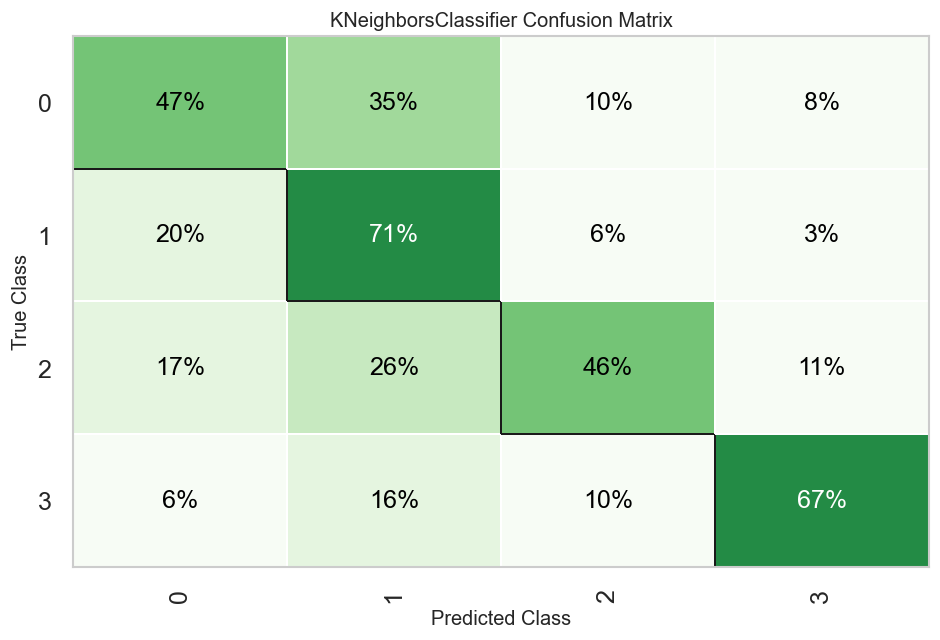

In [82]:
# Hold-out confusion matrix, row-normalized (share of each true class).
plot_model(
           knn_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': True}
           )

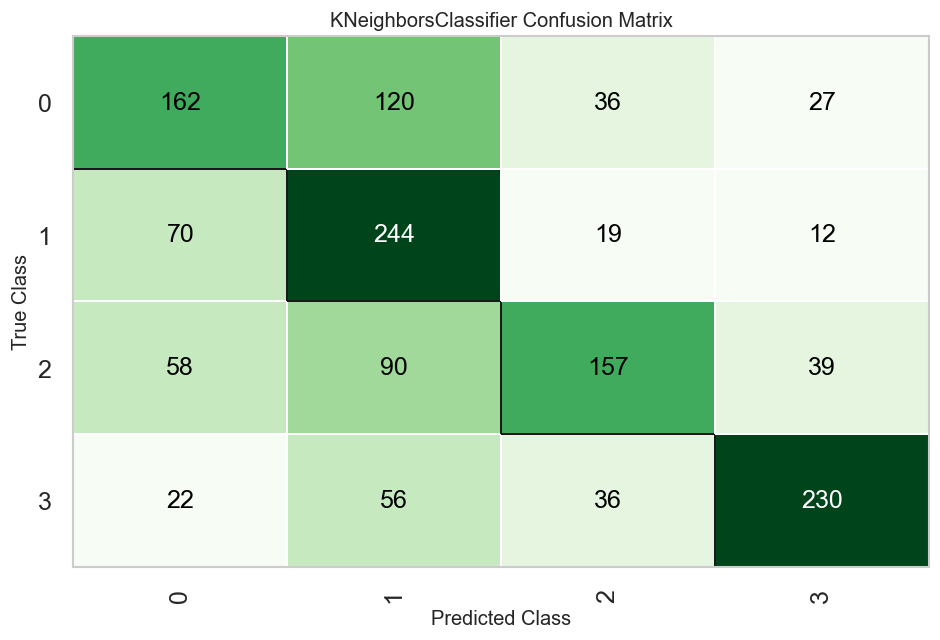

In [83]:
# Hold-out confusion matrix, absolute counts.
plot_model(
           knn_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': False}
           )

Per-class precision/recall/F1 on the hold-out set (KNN has no feature importances, so
the classification report is shown instead):

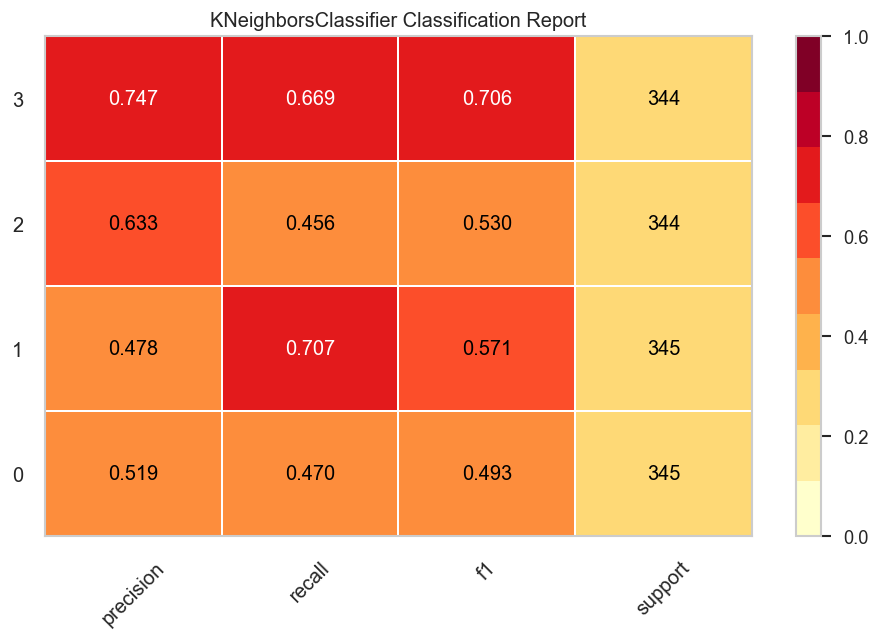

In [84]:
# Per-class precision / recall / F1 on the hold-out set.
plot_model(
           knn_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'class_report'
           )

The full deployable pipeline: every preprocessing step fitted during setup travels
with the model, so it can be applied to raw feature rows at inference time:

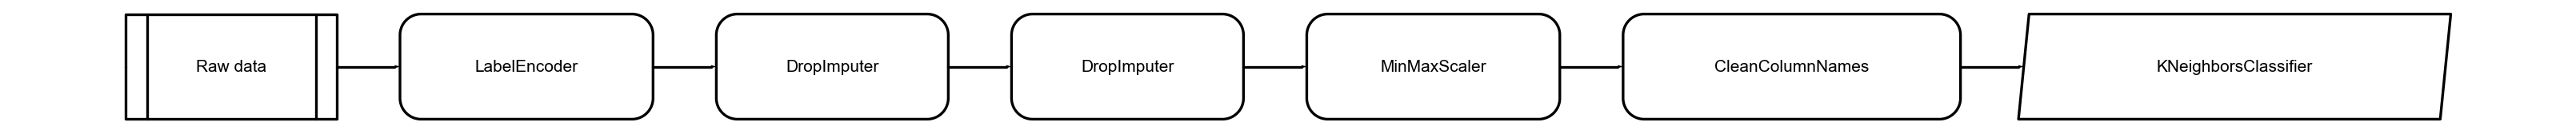

In [85]:
# The deployable pipeline: every preprocessing step fitted in setup() travels with the
# model and is applied automatically at inference time.
plot_model(
           knn_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'pipeline'
           )

Interactive plot browser (renders only in a live session; static preview shows no output):

In [86]:
# Interactive plot browser (widget renders only in a live session).
evaluate_model(knn_tuned)

Persist the entire pipeline (preprocessing + model) as a pickle for deployment:

In [87]:
# Persist the full pipeline (preprocessing + model) as a pickle for deployment.
save_model(knn_tuned, str(save_path_Best_Model_Multiclass_KNN))

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=DropImputer(columns=['Este '
                                                                      'Frecuency: '
                                                                      'Top 1',
                                                                      'Este '
                                                                      'Frecuency: '
                                                                      'Top 2',
                                                                      'Este '
                                                                      'Frecuency: '
                      

Model interpretability: permutation feature importance on the hold-out set (SHAP tree
explainers do not apply to this estimator type; the interactive Plotly output does not
render in a static preview).

In [88]:
# Permutation feature importance on the hold-out set (interactive Plotly figure).
interpret_model(
                knn_tuned,
                plot = 'pfi',
                feature = '3Frecuency Top 1'   # only used by 'correlation'/'pdp' plots; ignored here
                )

### 6.2.4 Random Forest

Train the model with 10-fold cross-validation. Reporting both CV-train and
CV-validation scores makes bias/variance visible: a high train score with a low
validation score would indicate overfitting.

In [89]:
# Train the model. create_model() runs the same 10-fold CV used by compare_models(),
# but reports the per-fold metrics. return_train_score=True adds the CV-train scores
# next to the CV-validation scores to make any overfitting visible.
rf_trained = create_model(
                            'rf',
                            round = 4,
                            verbose = True,
                            return_train_score = True,
                            cross_validation = True)

Hyperparameter search (random grid, 20 iterations) optimizing accuracy.
`choose_better=True` guarantees the returned model is never worse than the untuned
one. The best parameters found are printed below.

In [90]:
# Random-grid hyperparameter search optimizing accuracy. choose_better=True returns
# the original model whenever tuning does not improve it.
rf_tuned = tune_model(
                        rf_trained,
                        n_iter = n_iter,           # candidate configurations
                        optimize = 'Accuracy',     # tuning metric
                        choose_better = True,      # never return a worse model
                        tuner_verbose = True,
                        verbose = True,
                        round = 4
                        )

# Best hyperparameters found
rf_tuned.get_params()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8149,0.9522,0.8149,0.8174,0.8149,0.7532,0.7539
1,0.8076,0.9449,0.8076,0.8092,0.8078,0.7435,0.7439
2,0.8058,0.9442,0.8058,0.8064,0.8060,0.7411,0.7411
3,0.7931,0.9462,0.7931,0.7960,0.7941,0.7241,0.7244
4,0.8294,0.9532,0.8294,0.8291,0.8287,0.7725,0.7729
5,0.8040,0.9476,0.8040,0.8080,0.8050,0.7387,0.7392
6,0.8076,0.9452,0.8076,0.8069,0.8069,0.7435,0.7437
7,0.8076,0.9477,0.8076,0.8112,0.8087,0.7435,0.7440
8,0.8131,0.9500,0.8131,0.8138,0.8130,0.7508,0.7510


Fitting 10 folds for each of 20 candidates, totalling 200 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 261,
 'verbose': 0,
 'warm_start': False}

Hold-out performance: confusion matrix (row-normalized, then absolute counts):

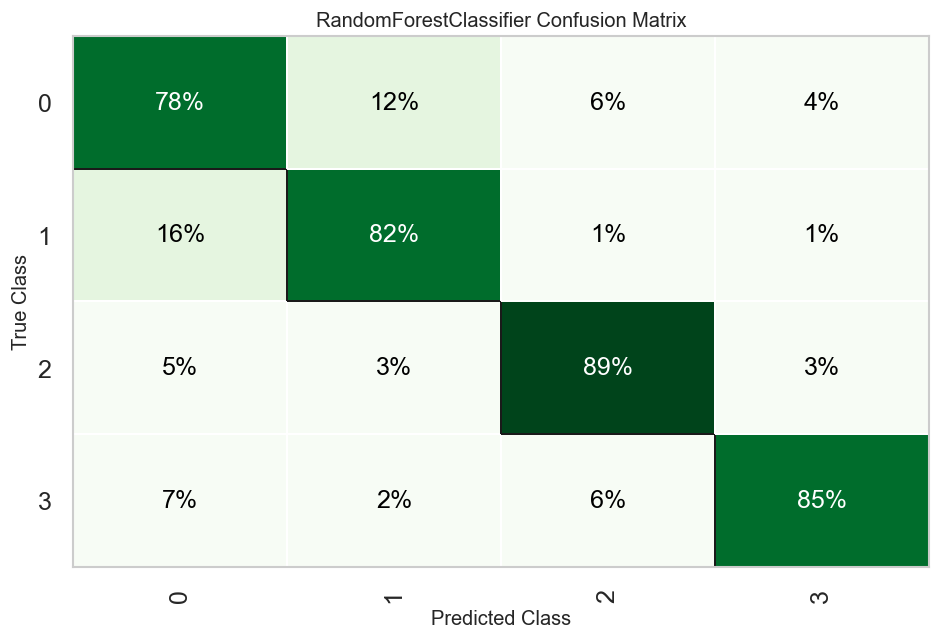

In [91]:
# Hold-out confusion matrix, row-normalized (share of each true class).
plot_model(
           rf_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': True}
           )

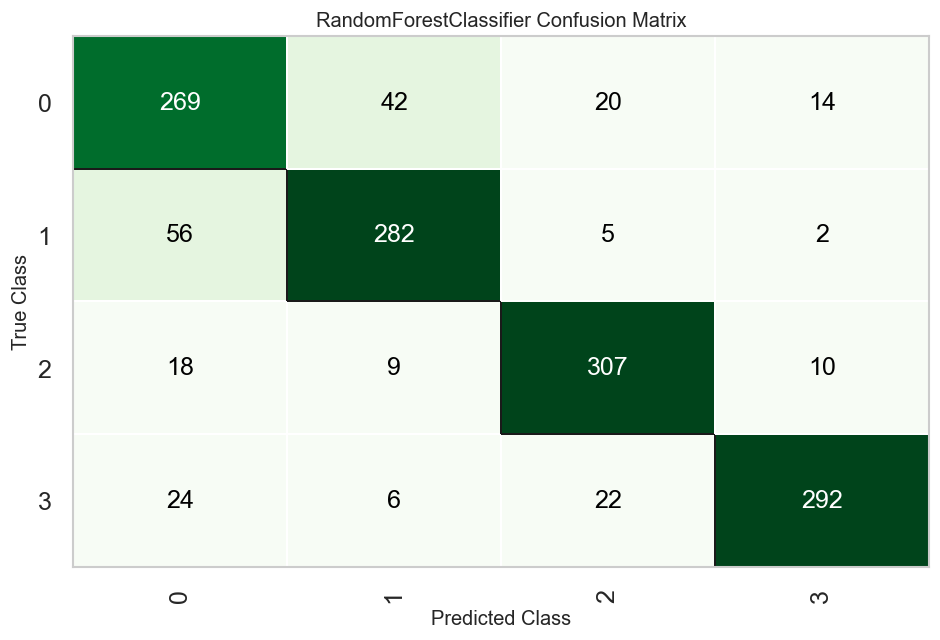

In [92]:
# Hold-out confusion matrix, absolute counts.
plot_model(
           rf_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': False}
           )

Feature importance on the hold-out set, showing which natural frequencies drive the prediction:

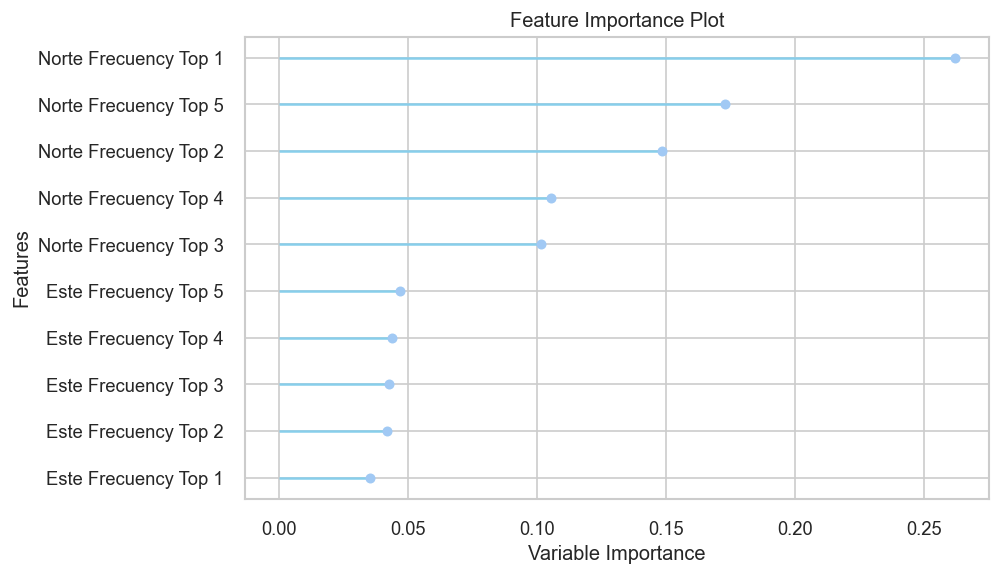

In [93]:
# Feature importance on the hold-out set.
plot_model(
           rf_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'feature_all'
           )

The full deployable pipeline: every preprocessing step fitted during setup travels
with the model, so it can be applied to raw feature rows at inference time:

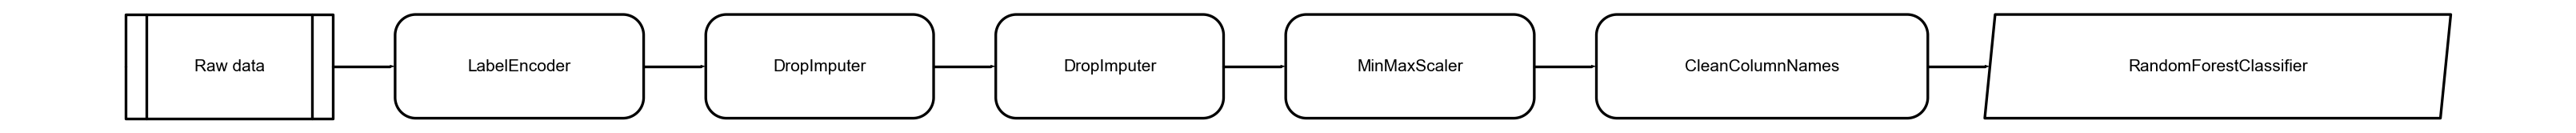

In [94]:
# The deployable pipeline: every preprocessing step fitted in setup() travels with the
# model and is applied automatically at inference time.
plot_model(
           rf_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'pipeline'
           )

Interactive plot browser (renders only in a live session; static preview shows no output):

In [95]:
# Interactive plot browser (widget renders only in a live session).
evaluate_model(rf_tuned)

Persist the entire pipeline (preprocessing + model) as a pickle for deployment:

In [96]:
# Persist the full pipeline (preprocessing + model) as a pickle for deployment.
save_model(rf_tuned, str(save_path_Best_Model_Multiclass_RF))

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=DropImputer(columns=['Este '
                                                                      'Frecuency: '
                                                                      'Top 1',
                                                                      'Este '
                                                                      'Frecuency: '
                                                                      'Top 2',
                                                                      'Este '
                                                                      'Frecuency: '
                      

Model interpretability: SHAP summary plot on the hold-out set: the contribution of
each natural frequency to individual predictions.

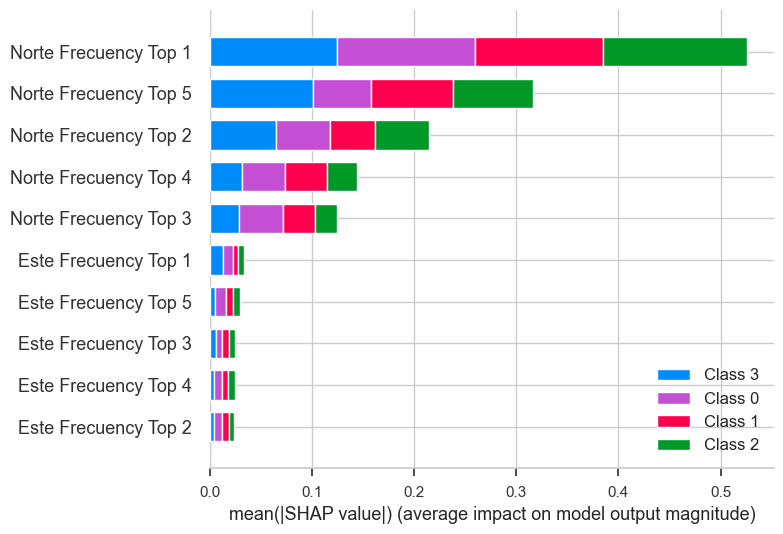

In [97]:
# SHAP summary plot on the hold-out set (TreeExplainer, tree-based models only).
interpret_model(
                rf_tuned,
                plot = 'summary',
                feature = '3Frecuency Top 1'   # only used by 'correlation'/'pdp' plots; ignored here
                )

### 6.2.5 Gradient Boosting

Train the model with 10-fold cross-validation. Reporting both CV-train and
CV-validation scores makes bias/variance visible: a high train score with a low
validation score would indicate overfitting.

In [98]:
# Train the model. create_model() runs the same 10-fold CV used by compare_models(),
# but reports the per-fold metrics. return_train_score=True adds the CV-train scores
# next to the CV-validation scores to make any overfitting visible.
gbc_trained = create_model(
                            'gbc',
                            round = 4,
                            verbose = True,
                            return_train_score = True,
                            cross_validation = True)

Hyperparameter search (random grid, 20 iterations) optimizing accuracy.
`choose_better=True` guarantees the returned model is never worse than the untuned
one. The best parameters found are printed below.

In [99]:
# Random-grid hyperparameter search optimizing accuracy. choose_better=True returns
# the original model whenever tuning does not improve it.
gbc_tuned = tune_model(
                        gbc_trained,
                        n_iter = n_iter,           # candidate configurations
                        optimize = 'Accuracy',     # tuning metric
                        choose_better = True,      # never return a worse model
                        tuner_verbose = True,
                        verbose = True,
                        round = 4
                        )

# Best hyperparameters found
gbc_tuned.get_params()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8584,0.0000,0.8584,0.8605,0.8589,0.8113,0.8116
1,0.8475,0.0000,0.8475,0.8505,0.8477,0.7967,0.7976
2,0.8221,0.0000,0.8221,0.8257,0.8234,0.7629,0.7631
3,0.8330,0.0000,0.8330,0.8371,0.8345,0.7774,0.7778
4,0.8693,0.0000,0.8693,0.8719,0.8699,0.8258,0.8262
5,0.8294,0.0000,0.8294,0.8340,0.8308,0.7725,0.7730
6,0.8385,0.0000,0.8385,0.8393,0.8386,0.7846,0.7848
7,0.8439,0.0000,0.8439,0.8448,0.8442,0.7919,0.7920
8,0.8367,0.0000,0.8367,0.8374,0.8367,0.7822,0.7824


Fitting 10 folds for each of 20 candidates, totalling 200 fits


{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.15,
 'loss': 'log_loss',
 'max_depth': 8,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0002,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 220,
 'n_iter_no_change': None,
 'random_state': 261,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

Hold-out performance: confusion matrix (row-normalized, then absolute counts):

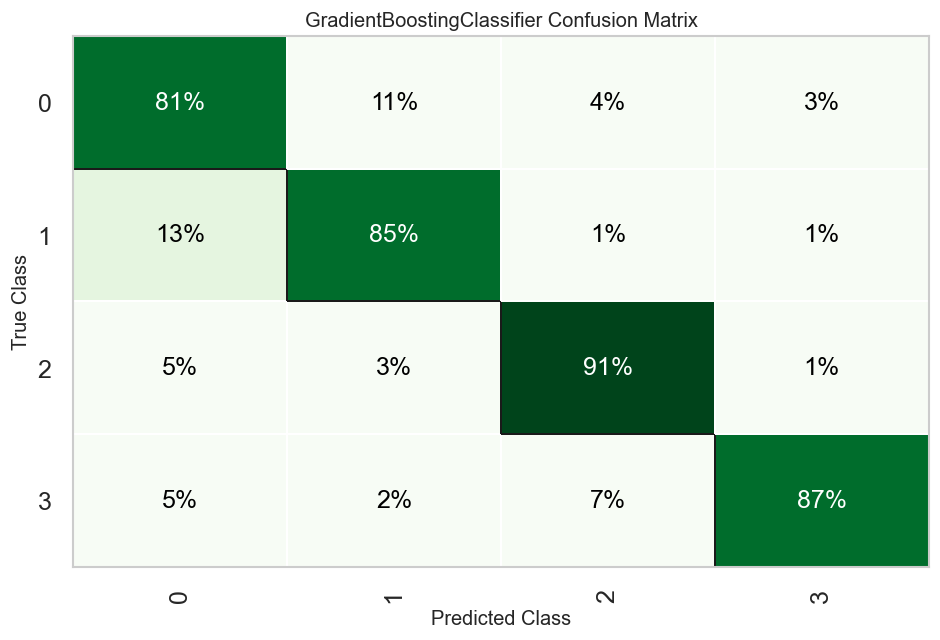

In [100]:
# Hold-out confusion matrix, row-normalized (share of each true class).
plot_model(
           gbc_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': True}
           )

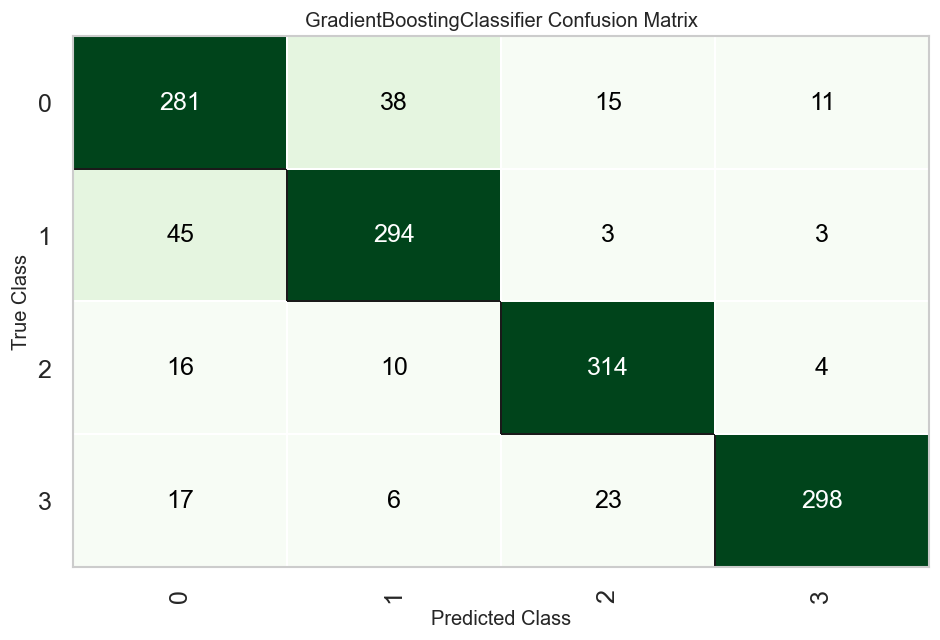

In [101]:
# Hold-out confusion matrix, absolute counts.
plot_model(
           gbc_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': False}
           )

Feature importance on the hold-out set, showing which natural frequencies drive the prediction:

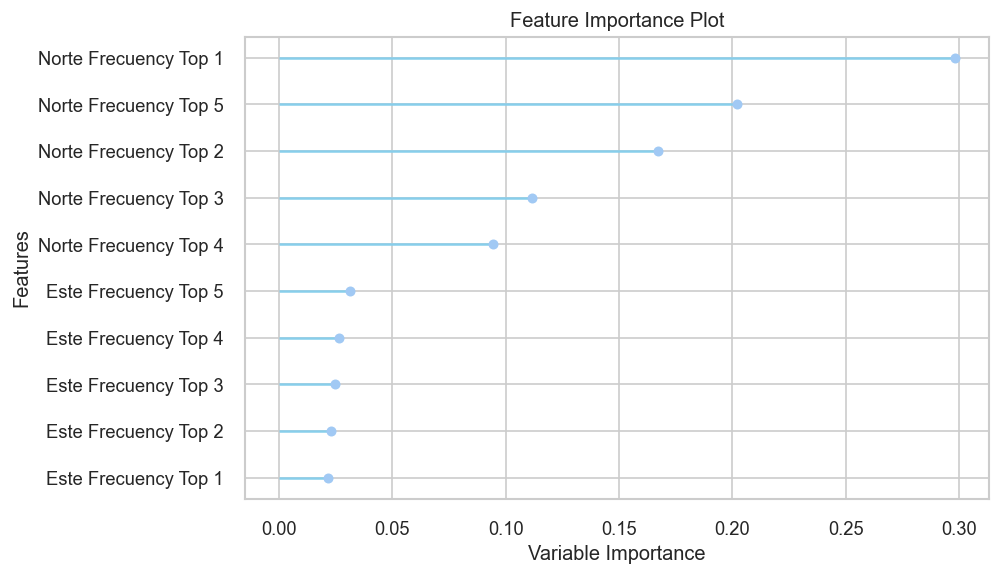

In [102]:
# Feature importance on the hold-out set.
plot_model(
           gbc_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'feature_all'
           )

The full deployable pipeline: every preprocessing step fitted during setup travels
with the model, so it can be applied to raw feature rows at inference time:

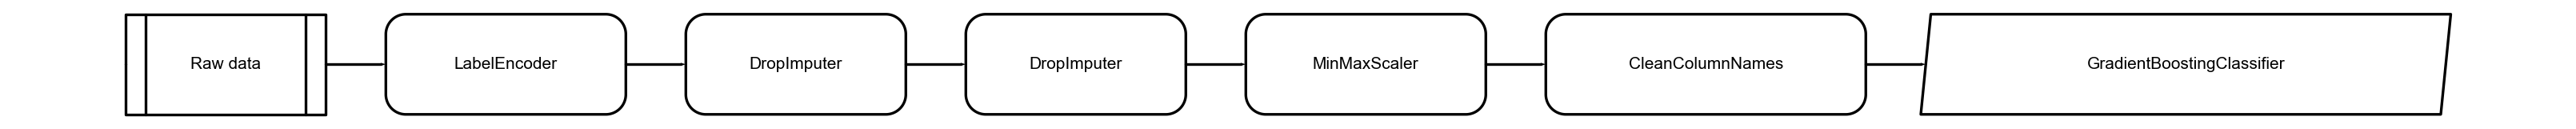

In [103]:
# The deployable pipeline: every preprocessing step fitted in setup() travels with the
# model and is applied automatically at inference time.
plot_model(
           gbc_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'pipeline'
           )

Interactive plot browser (renders only in a live session; static preview shows no output):

In [104]:
# Interactive plot browser (widget renders only in a live session).
evaluate_model(gbc_tuned)

Persist the entire pipeline (preprocessing + model) as a pickle for deployment:

In [105]:
# Persist the full pipeline (preprocessing + model) as a pickle for deployment.
save_model(gbc_tuned, str(save_path_Best_Model_Multiclass_GBC))

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=DropImputer(columns=['Este '
                                                                      'Frecuency: '
                                                                      'Top 1',
                                                                      'Este '
                                                                      'Frecuency: '
                                                                      'Top 2',
                                                                      'Este '
                                                                      'Frecuency: '
                      

Model interpretability: permutation feature importance on the hold-out set (SHAP tree
explainers do not apply to this estimator type; the interactive Plotly output does not
render in a static preview).

In [106]:
# Permutation feature importance on the hold-out set (interactive Plotly figure).
interpret_model(
                gbc_tuned,
                plot = 'pfi',
                feature = '3Frecuency Top 1'   # only used by 'correlation'/'pdp' plots; ignored here
                )

### 6.2.6 LightGBM

Train the model with 10-fold cross-validation. Reporting both CV-train and
CV-validation scores makes bias/variance visible: a high train score with a low
validation score would indicate overfitting.

In [107]:
# Train the model. create_model() runs the same 10-fold CV used by compare_models(),
# but reports the per-fold metrics. return_train_score=True adds the CV-train scores
# next to the CV-validation scores to make any overfitting visible.
lightgbm_trained = create_model(
                            'lightgbm',
                            round = 4,
                            verbose = True,
                            return_train_score = True,
                            cross_validation = True)

Hyperparameter search (random grid, 20 iterations) optimizing accuracy.
`choose_better=True` guarantees the returned model is never worse than the untuned
one. The best parameters found are printed below.

In [108]:
# Random-grid hyperparameter search optimizing accuracy. choose_better=True returns
# the original model whenever tuning does not improve it.
lightgbm_tuned = tune_model(
                        lightgbm_trained,
                        n_iter = n_iter,           # candidate configurations
                        optimize = 'Accuracy',     # tuning metric
                        choose_better = True,      # never return a worse model
                        tuner_verbose = True,
                        verbose = True,
                        round = 4
                        )

# Best hyperparameters found
lightgbm_tuned.get_params()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8566,0.9743,0.8566,0.8567,0.8566,0.8088,0.8089
1,0.8748,0.9696,0.8748,0.8797,0.8759,0.8330,0.8339
2,0.8439,0.9672,0.8439,0.8461,0.8447,0.7919,0.7921
3,0.8403,0.9628,0.8403,0.8440,0.8418,0.7871,0.7873
4,0.8675,0.9728,0.8675,0.8686,0.8677,0.8234,0.8236
5,0.8512,0.9693,0.8512,0.8553,0.8524,0.8016,0.8021
6,0.8421,0.9682,0.8421,0.8433,0.8424,0.7895,0.7897
7,0.8548,0.9719,0.8548,0.8573,0.8557,0.8064,0.8066
8,0.8548,0.9741,0.8548,0.8578,0.8555,0.8064,0.8069


Fitting 10 folds for each of 20 candidates, totalling 200 fits
[... 81569 lines of verbose training output truncated for readability ...]


{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.05,
 'max_depth': -1,
 'min_child_samples': 21,
 'min_child_weight': 0.001,
 'min_split_gain': 0.3,
 'n_estimators': 240,
 'n_jobs': -1,
 'num_leaves': 30,
 'objective': None,
 'random_state': 261,
 'reg_alpha': 0.001,
 'reg_lambda': 0.5,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'device': 'gpu',
 'feature_fraction': 0.4,
 'bagging_freq': 2,
 'bagging_fraction': 0.7}

Hold-out performance: confusion matrix (row-normalized, then absolute counts):

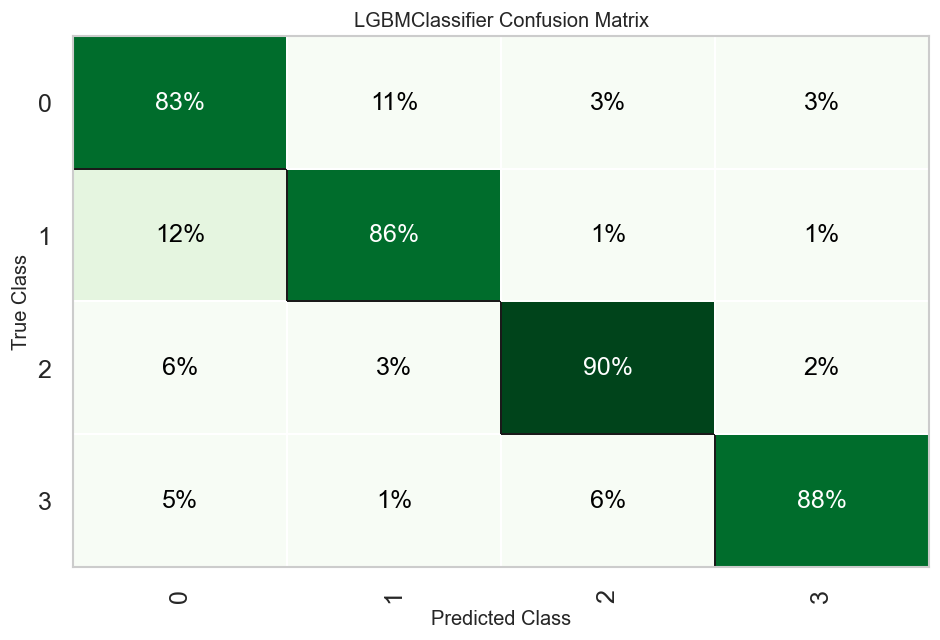

In [109]:
# Hold-out confusion matrix, row-normalized (share of each true class).
plot_model(
           lightgbm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': True}
           )

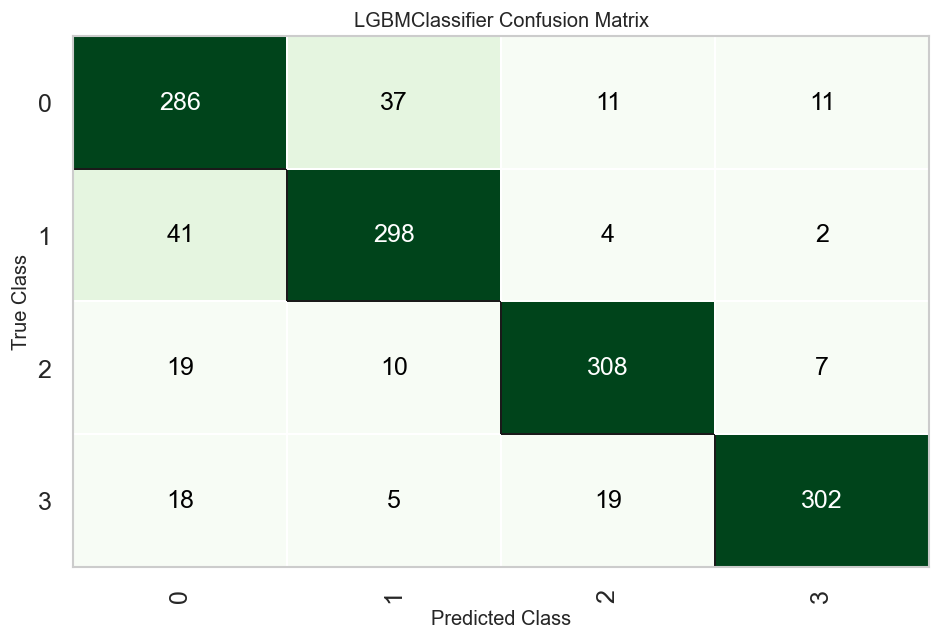

In [110]:
# Hold-out confusion matrix, absolute counts.
plot_model(
           lightgbm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'confusion_matrix', plot_kwargs = {'percent': False}
           )

Feature importance on the hold-out set, showing which natural frequencies drive the prediction:

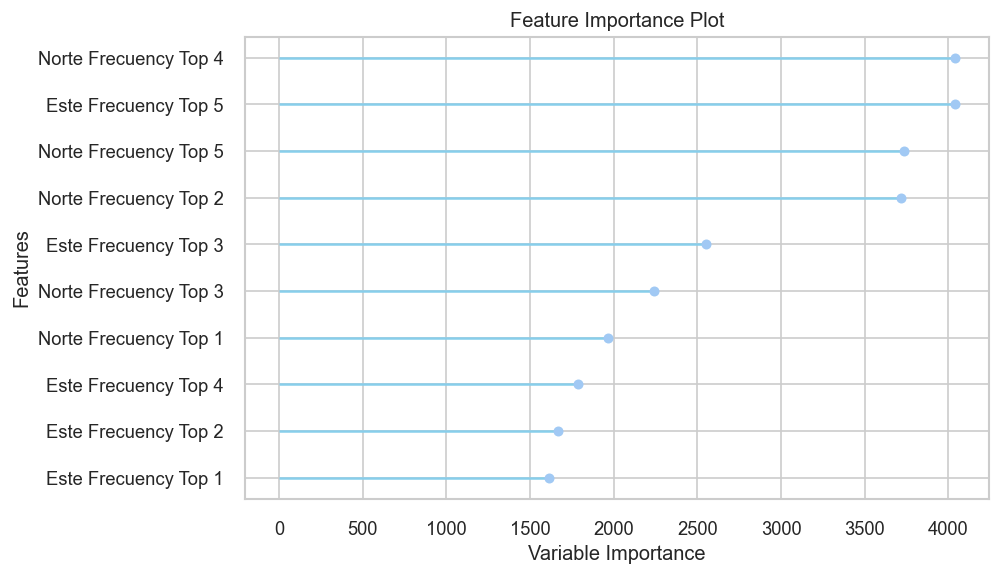

In [111]:
# Feature importance on the hold-out set.
plot_model(
           lightgbm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'feature_all'
           )

Model interpretability: SHAP summary plot on the hold-out set: the contribution of
each natural frequency to individual predictions.

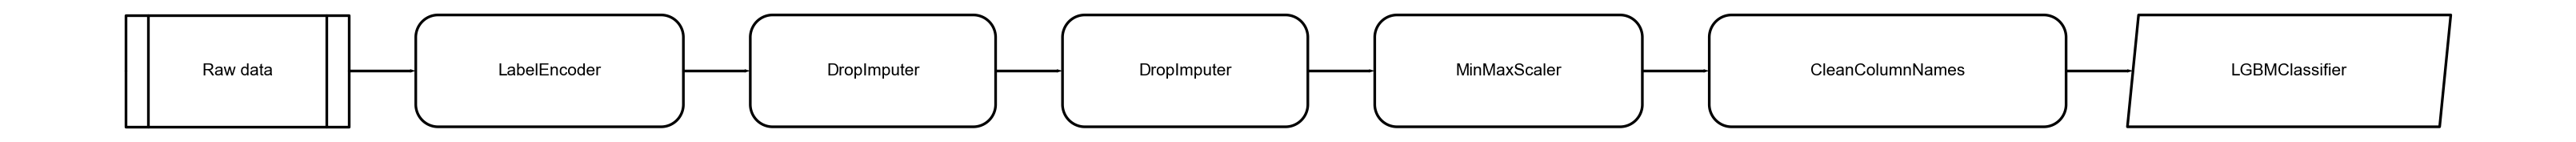

In [112]:
# SHAP summary plot on the hold-out set (TreeExplainer, tree-based models only).
interpret_model(
                lightgbm_tuned,
                plot = 'summary',
                feature = '3Frecuency Top 1'   # only used by 'correlation'/'pdp' plots; ignored here
                )

The full deployable pipeline: every preprocessing step fitted during setup travels
with the model, so it can be applied to raw feature rows at inference time:

In [113]:
# The deployable pipeline: every preprocessing step fitted in setup() travels with the
# model and is applied automatically at inference time.
plot_model(
           lightgbm_tuned,
           scale = 1.2,
           verbose = True,
           plot = 'pipeline'
           )

Interactive plot browser (renders only in a live session; static preview shows no output):

In [114]:
# Interactive plot browser (widget renders only in a live session).
evaluate_model(lightgbm_tuned)

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=DropImputer(columns=['Este '
                                                                      'Frecuency: '
                                                                      'Top 1',
                                                                      'Este '
                                                                      'Frecuency: '
                                                                      'Top 2',
                                                                      'Este '
                                                                      'Frecuency: '
                      

Persist the entire pipeline (preprocessing + model) as a pickle for deployment:

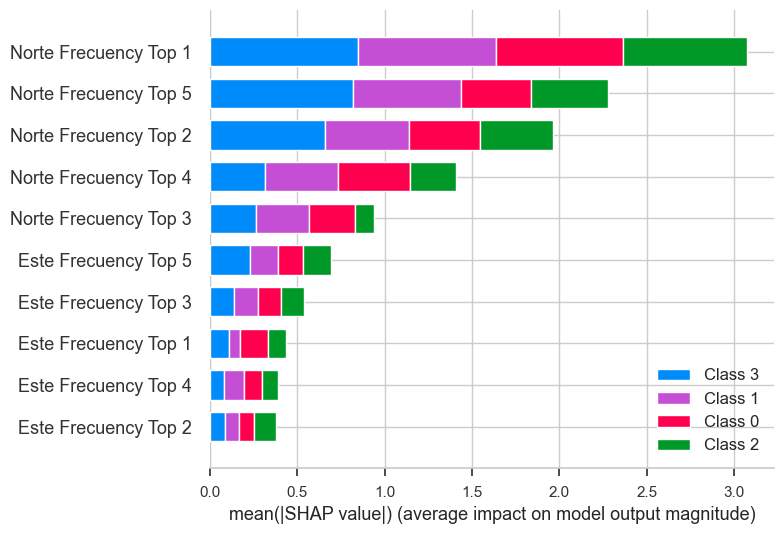

In [115]:
# Persist the full pipeline (preprocessing + model) as a pickle for deployment.
save_model(lightgbm_tuned, str(save_path_Best_Model_Multiclass_LightGBM))

### 6.2.7 Model comparison on the hold-out set

Final evaluation: every tuned model predicts the hold-out split (20% of the data,
stratified, never seen during training or tuning). These are the headline results.

In [116]:
# Predict the hold-out split with every tuned model. With data=None, predict_model()
# scores the hold-out set automatically and prints the metrics per model.
pred_holdout_svm = predict_model(estimator = svm_tuned,
                             data = None,
                             )
pred_holdout_knn = predict_model(estimator = knn_tuned,
                             data = None,
                             )
pred_holdout_rf = predict_model(estimator = rf_tuned,
                             data = None,
                             )
pred_holdout_gbc = predict_model(estimator = gbc_tuned,
                             data = None,
                             )
pred_holdout_lightgbm = predict_model(estimator = lightgbm_tuned,
                             data = None,
                             )

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,SVM - Linear Kernel,0.3882,0,0.3882,0.5216,0.3451,0.1842,0.2318


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.5755,0.8277,0.5755,0.5942,0.5749,0.4339,0.4399


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.8345,0.9573,0.8345,0.8375,0.8354,0.7794,0.7797


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.8614,0.9690,0.8614,0.8637,0.8620,0.8152,0.8155


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8665,0.9741,0.8665,0.8688,0.8672,0.8220,0.8222
